# Vision Transformer (ViT) on CIFAR-10 from Scratch

## O objetivo desse projeto é auxilar pessoas que estão inciando seus estudos em Visão Computacional avançada 

Essa é uma implementação didática de um Vision Transformer para classificação de imagens no dataset CIFAR-10, com análises aprofundadas de:
- Embeddings (t-SNE, UMAP, PCA)
- Attention maps e rollout
- Projeção linear do classificador
- Métricas de performance (GPU, Loss, Accuracy, Recall, Precision, F1)
- Visualizações detalhadas de cada componente

## Fundamentos Teóricos

### Self-Attention Mechanism
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

### Multi-Head Attention
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,...,\text{head}_h)W^O$$
onde $\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$

### Transformer Block
$$\text{Output} = \text{LN}(x + \text{MLP}(\text{LN}(x + \text{MSA}(x))))$$

### Referências 
- Dosovitskiy et al. (2020) - An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale (Vision Transformer)
- Vaswani et al. (2017) - Attention is All You Need (Transformer)

## 1. Configuração e Imports

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, cohen_kappa_score,
    classification_report, roc_auc_score
)
import umap
from typing import Tuple, Optional, List, Dict, Any
from collections import defaultdict
from dataclasses import dataclass
import time
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")

/Users/wamat/Desktop/Pytorch-Collections/pytorch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
PyTorch Version: 2.10.0


In [25]:
@dataclass
class ViTConfig:
    """Configuração do Vision Transformer."""
    
    image_size: Tuple[int, int] = (32, 32)
    patch_size: int = 4
    num_classes: int = 10
    embedding_dim: int = 256
    num_heads: int = 8
    num_layers: int = 6
    mlp_ratio: float = 4.0
    dropout: float = 0.1
    attention_dropout: float = 0.1
    
    epochs: int = 3
    batch_size: int = 128
    learning_rate: float = 3e-4
    weight_decay: float = 0.1
    warmup_epochs: int = 2
    label_smoothing: float = 0.1
    
    patience: int = 3
    min_delta: float = 0.001
    gradient_clip_norm: float = 1.0
    
    num_workers: int = 2
    pin_memory: bool = False
    
    @property
    def num_patches(self) -> int:
        return (self.image_size[0] // self.patch_size) * (self.image_size[1] // self.patch_size)
    
    @property
    def mlp_hidden_dim(self) -> int:
        return int(self.embedding_dim * self.mlp_ratio)

config = ViTConfig()

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print(f"Configuração do Modelo:")
print(f"  Patches: {config.num_patches}")
print(f"  Embedding Dim: {config.embedding_dim}")
print(f"  Num Heads: {config.num_heads}")
print(f"  Num Layers: {config.num_layers}")
print(f"  MLP Hidden Dim: {config.mlp_hidden_dim}")
print(f"  Total Epochs: {config.epochs}")

Configuração do Modelo:
  Patches: 64
  Embedding Dim: 256
  Num Heads: 8
  Num Layers: 6
  MLP Hidden Dim: 1024
  Total Epochs: 3


## 2. Preparação dos Dados e Análise Exploratória

In [26]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

val_size = 5000
train_size = len(train_dataset) - val_size
train_indices = list(range(train_size))
val_indices = list(range(train_size, len(train_dataset)))

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory
)

val_loader = DataLoader(
    val_subset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    pin_memory=config.pin_memory
)

print(f"Dataset CIFAR-10:")
print(f"  Train: {len(train_subset)} amostras")
print(f"  Validation: {len(val_subset)} amostras")
print(f"  Test: {len(test_dataset)} amostras")
print(f"  Batches por época (train): {len(train_loader)}")

Dataset CIFAR-10:
  Train: 45000 amostras
  Validation: 5000 amostras
  Test: 10000 amostras
  Batches por época (train): 352


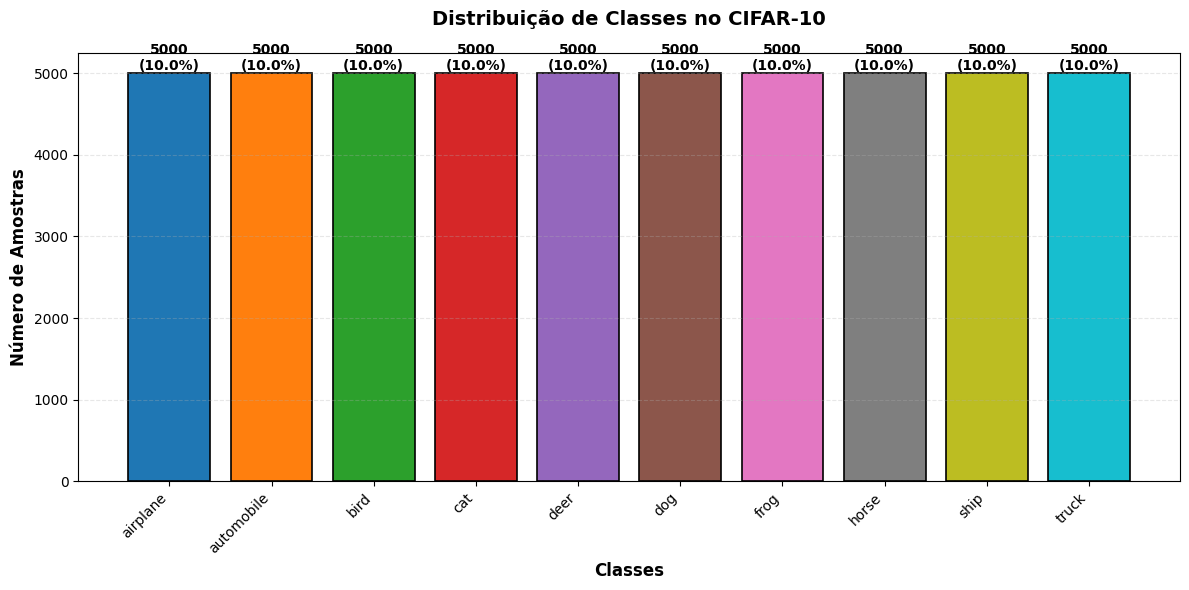

In [27]:
def visualize_dataset_distribution(dataset: datasets.CIFAR10, class_names: List[str]) -> None:
    """
    Visualiza a distribuição de classes no dataset.
    
    Args:
        dataset: Dataset CIFAR-10
        class_names: Lista com nomes das classes
    """
    labels = [label for _, label in dataset]
    unique, counts = np.unique(labels, return_counts=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    bars = ax.bar(class_names, counts, color=colors, edgecolor='black', linewidth=1.2)
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({count/sum(counts)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Classes', fontsize=12, fontweight='bold')
    ax.set_ylabel('Número de Amostras', fontsize=12, fontweight='bold')
    ax.set_title('Distribuição de Classes no CIFAR-10', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

visualize_dataset_distribution(train_dataset, CLASS_NAMES)

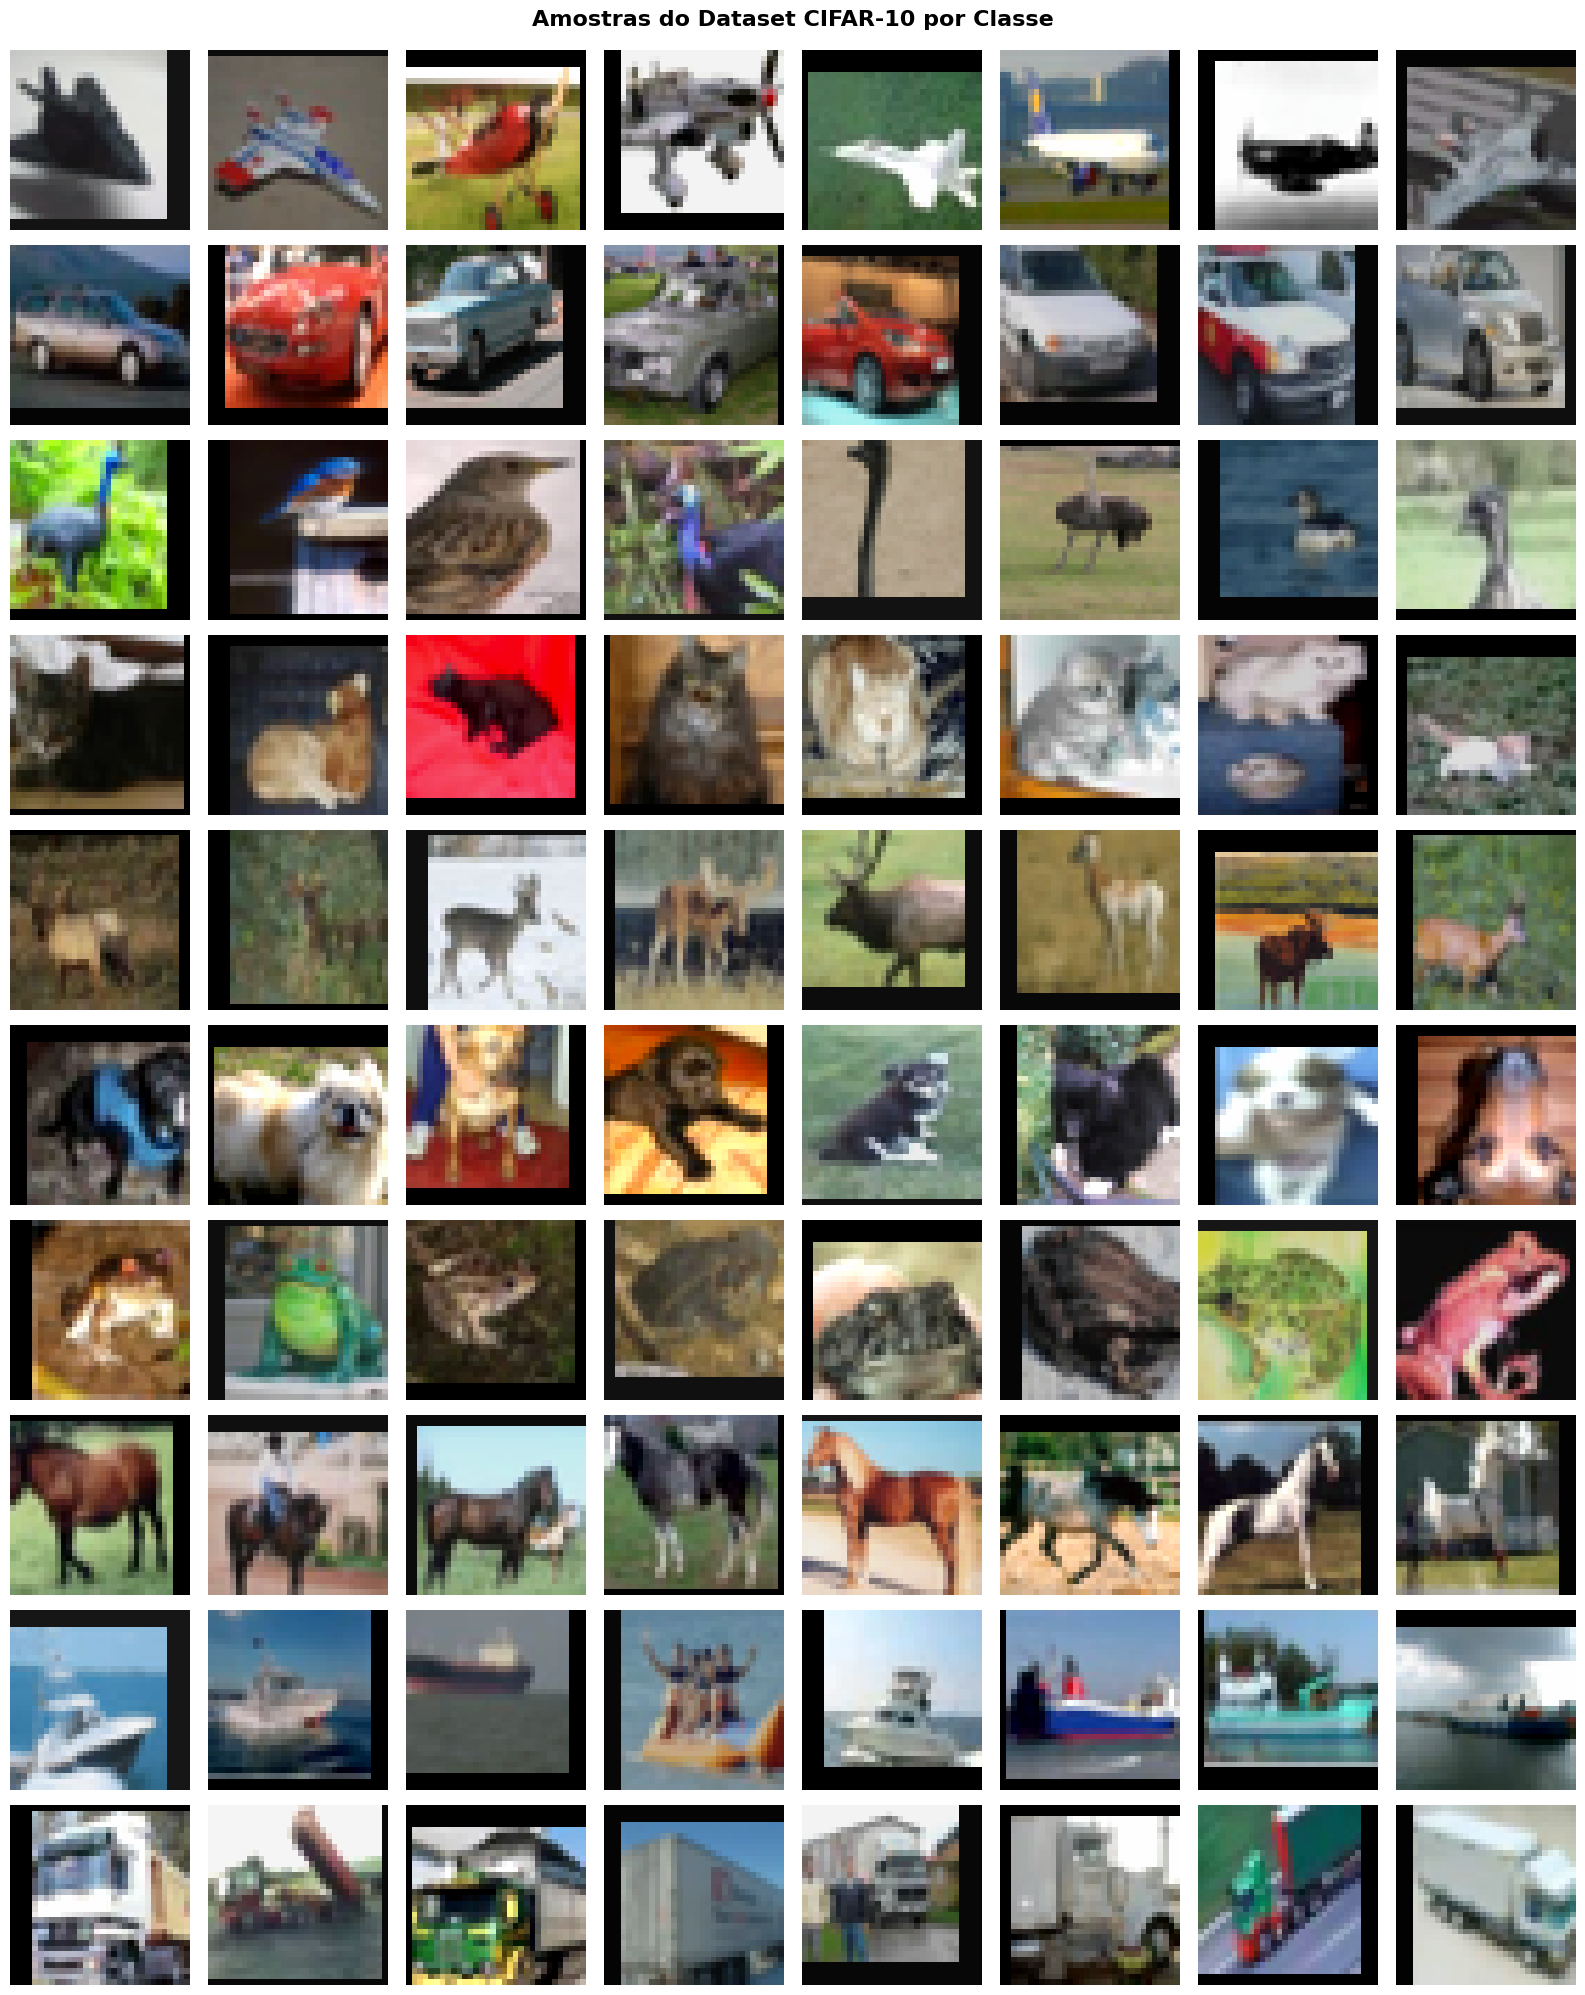

In [28]:
def visualize_samples_grid(dataset: datasets.CIFAR10, class_names: List[str], samples_per_class: int = 8) -> None:
    """
    Visualiza grid de amostras por classe.
    
    Args:
        dataset: Dataset CIFAR-10
        class_names: Lista com nomes das classes
        samples_per_class: Número de amostras por classe
    """
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(16, 20))
    
    class_samples = {i: [] for i in range(len(class_names))}
    
    for idx, (img, label) in enumerate(dataset):
        if len(class_samples[label]) < samples_per_class:
            class_samples[label].append(img)
        if all(len(samples) == samples_per_class for samples in class_samples.values()):
            break
    
    for class_idx, class_name in enumerate(class_names):
        for sample_idx in range(samples_per_class):
            ax = axes[class_idx, sample_idx]
            img = class_samples[class_idx][sample_idx]
            
            img_denorm = img.numpy().transpose(1, 2, 0)
            mean = np.array([0.4914, 0.4822, 0.4465])
            std = np.array([0.2470, 0.2435, 0.2616])
            img_denorm = img_denorm * std + mean
            img_denorm = np.clip(img_denorm, 0, 1)
            
            ax.imshow(img_denorm)
            ax.axis('off')
            
            if sample_idx == 0:
                ax.set_ylabel(class_name, fontsize=12, fontweight='bold', rotation=0, 
                             labelpad=40, va='center')
    
    plt.suptitle('Amostras do Dataset CIFAR-10 por Classe', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

visualize_samples_grid(train_dataset, CLASS_NAMES, samples_per_class=8)

## 3. Componentes do Vision Transformer

### 3.1 Patch Embedding

O Patch Embedding converte a imagem em uma sequência de patches e projeta cada patch em um espaço de embedding de dimensão $d$.

**Equação:**
$$\text{Patch}(x) = \text{Conv2D}(x, \text{kernel}=P, \text{stride}=P)$$

onde $P$ é o tamanho do patch.

In [29]:
class PatchEmbedding(nn.Module):
    """
    Converte imagem em sequência de patches com projeção linear.
    
    Args:
        image_size: Tamanho da imagem (H, W)
        patch_size: Tamanho de cada patch (P, P)
        in_channels: Canais de entrada (3 para RGB)
        embedding_dim: Dimensão do espaço de embedding
        
    Shape:
        - Input: (batch_size, in_channels, H, W)
        - Output: (batch_size, num_patches, embedding_dim)
        
    References:
        Dosovitskiy et al. (2020) - An Image is Worth 16x16 Words
    """
    
    def __init__(
        self,
        image_size: Tuple[int, int],
        patch_size: int,
        in_channels: int = 3,
        embedding_dim: int = 768
    ) -> None:
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size[0] // patch_size) * (image_size[1] // patch_size)
        
        self.projection = nn.Conv2d(
            in_channels,
            embedding_dim,
            kernel_size=patch_size,
            stride=patch_size
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch_size, in_channels, H, W)
            
        Returns:
            (batch_size, num_patches, embedding_dim)
        """
        x = self.projection(x)
        x = x.flatten(2).transpose(1, 2)
        return x

patch_embed_test = PatchEmbedding(
    image_size=config.image_size,
    patch_size=config.patch_size,
    in_channels=3,
    embedding_dim=config.embedding_dim
)

test_input = torch.randn(2, 3, 32, 32)
test_output = patch_embed_test(test_input)
print(f"PatchEmbedding Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Num patches: {config.num_patches}")

PatchEmbedding Test:
  Input shape: torch.Size([2, 3, 32, 32])
  Output shape: torch.Size([2, 64, 256])
  Num patches: 64


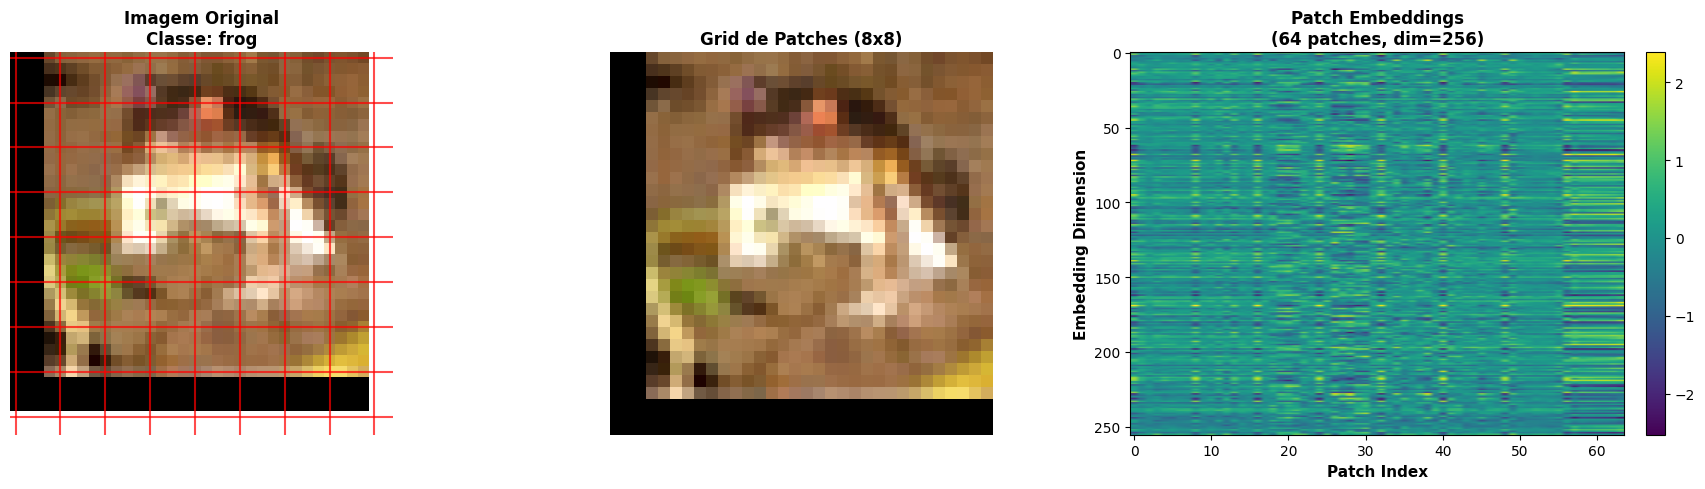

In [30]:
def visualize_patch_embedding(
    image: torch.Tensor,
    patch_size: int,
    patch_embedder: PatchEmbedding,
    class_name: str = ""
) -> None:
    """
    Visualiza o processo de patchificação e embedding.
    
    Args:
        image: Tensor (C, H, W) normalizado
        patch_size: Tamanho do patch
        patch_embedder: Instância de PatchEmbedding
        class_name: Nome da classe da imagem
    """
    img_denorm = image.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img_denorm = img_denorm * std + mean
    img_denorm = np.clip(img_denorm, 0, 1)
    
    H, W = image.shape[1], image.shape[2]
    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    
    fig = plt.figure(figsize=(18, 5))
    
    ax1 = plt.subplot(1, 3, 1)
    ax1.imshow(img_denorm)
    ax1.set_title(f'Imagem Original\nClasse: {class_name}', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    for i in range(num_patches_h + 1):
        ax1.axhline(y=i*patch_size, color='red', linewidth=1.5, alpha=0.7)
    for j in range(num_patches_w + 1):
        ax1.axvline(x=j*patch_size, color='red', linewidth=1.5, alpha=0.7)
    
    ax2 = plt.subplot(1, 3, 2)
    patches_grid = np.zeros((num_patches_h * patch_size, num_patches_w * patch_size, 3))
    
    for i in range(num_patches_h):
        for j in range(num_patches_w):
            patch = img_denorm[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            patches_grid[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = patch
    
    ax2.imshow(patches_grid)
    ax2.set_title(f'Grid de Patches ({num_patches_h}x{num_patches_w})', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    with torch.no_grad():
        embeddings = patch_embedder(image.unsqueeze(0))
        embeddings_np = embeddings.squeeze(0).cpu().numpy()
    
    ax3 = plt.subplot(1, 3, 3)
    im = ax3.imshow(embeddings_np.T, cmap='viridis', aspect='auto')
    ax3.set_xlabel('Patch Index', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Embedding Dimension', fontsize=11, fontweight='bold')
    ax3.set_title(f'Patch Embeddings\n({embeddings_np.shape[0]} patches, dim={embeddings_np.shape[1]})', 
                  fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

sample_img, sample_label = train_dataset[0]
visualize_patch_embedding(
    sample_img, 
    config.patch_size, 
    patch_embed_test,
    CLASS_NAMES[sample_label]
)

### 3.2 Multi-Head Self-Attention

O mecanismo de atenção permite que o modelo foque em diferentes partes da sequência.

**Equação:**
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Multi-Head:**
$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,...,\text{head}_h)W^O$$

In [31]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention mechanism.
    
    Args:
        embedding_dim: Dimensão do embedding
        num_heads: Número de cabeças de atenção
        dropout: Taxa de dropout
        
    Shape:
        - Input: (batch_size, seq_len, embedding_dim)
        - Output: (batch_size, seq_len, embedding_dim)
        - Attention weights: (batch_size, num_heads, seq_len, seq_len)
    """
    
    def __init__(
        self,
        embedding_dim: int,
        num_heads: int = 8,
        dropout: float = 0.1
    ) -> None:
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim deve ser divisível por num_heads"
        
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.qkv = nn.Linear(embedding_dim, embedding_dim * 3)
        self.projection = nn.Linear(embedding_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        
        self.attention_weights = None
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch_size, seq_len, embedding_dim)
            
        Returns:
            (batch_size, seq_len, embedding_dim)
        """
        batch_size, seq_len, _ = x.shape
        
        qkv = self.qkv(x).reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attention_scores = (q @ k.transpose(-2, -1)) * self.scale
        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)
        
        self.attention_weights = attention_probs.detach()
        
        out = attention_probs @ v
        out = out.transpose(1, 2).reshape(batch_size, seq_len, self.embedding_dim)
        out = self.projection(out)
        out = self.dropout(out)
        
        return out

mhsa_test = MultiHeadSelfAttention(
    embedding_dim=config.embedding_dim,
    num_heads=config.num_heads,
    dropout=config.dropout
)

test_input = torch.randn(2, config.num_patches + 1, config.embedding_dim)
test_output = mhsa_test(test_input)
print(f"MultiHeadSelfAttention Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Attention weights shape: {mhsa_test.attention_weights.shape}")

MultiHeadSelfAttention Test:
  Input shape: torch.Size([2, 65, 256])
  Output shape: torch.Size([2, 65, 256])
  Attention weights shape: torch.Size([2, 8, 65, 65])


### 3.3 MLP (Feed-Forward Network)

Rede feed-forward com ativação GELU aplicada após a atenção.

**Equação:**
$$\text{MLP}(x) = \text{GELU}(xW_1 + b_1)W_2 + b_2$$

In [32]:
class MLP(nn.Module):
    """
    Feed-Forward Network com GELU activation.
    
    Args:
        embedding_dim: Dimensão do embedding
        hidden_dim: Dimensão da camada oculta
        dropout: Taxa de dropout
        
    Shape:
        - Input: (batch_size, seq_len, embedding_dim)
        - Output: (batch_size, seq_len, embedding_dim)
    """
    
    def __init__(
        self,
        embedding_dim: int,
        hidden_dim: int,
        dropout: float = 0.1
    ) -> None:
        super().__init__()
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embedding_dim)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.GELU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch_size, seq_len, embedding_dim)
            
        Returns:
            (batch_size, seq_len, embedding_dim)
        """
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

mlp_test = MLP(
    embedding_dim=config.embedding_dim,
    hidden_dim=config.mlp_hidden_dim,
    dropout=config.dropout
)

test_input = torch.randn(2, config.num_patches + 1, config.embedding_dim)
test_output = mlp_test(test_input)
print(f"MLP Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print(f"  Hidden dim: {config.mlp_hidden_dim}")

MLP Test:
  Input shape: torch.Size([2, 65, 256])
  Output shape: torch.Size([2, 65, 256])
  Hidden dim: 1024


### 3.4 Transformer Block

Bloco completo do Transformer com atenção e MLP, incluindo Layer Normalization e conexões residuais.

**Equação:**
$$\text{Output} = \text{LN}(x + \text{MLP}(\text{LN}(x + \text{MSA}(x))))$$

In [33]:
class TransformerBlock(nn.Module):
    """
    Bloco completo do Transformer com MSA e MLP.
    
    Args:
        embedding_dim: Dimensão do embedding
        num_heads: Número de cabeças de atenção
        mlp_hidden_dim: Dimensão da camada oculta do MLP
        dropout: Taxa de dropout
        
    Shape:
        - Input: (batch_size, seq_len, embedding_dim)
        - Output: (batch_size, seq_len, embedding_dim)
    """
    
    def __init__(
        self,
        embedding_dim: int,
        num_heads: int,
        mlp_hidden_dim: int,
        dropout: float = 0.1
    ) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.attention = MultiHeadSelfAttention(embedding_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embedding_dim)
        self.mlp = MLP(embedding_dim, mlp_hidden_dim, dropout)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch_size, seq_len, embedding_dim)
            
        Returns:
            (batch_size, seq_len, embedding_dim)
        """
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

transformer_block_test = TransformerBlock(
    embedding_dim=config.embedding_dim,
    num_heads=config.num_heads,
    mlp_hidden_dim=config.mlp_hidden_dim,
    dropout=config.dropout
)

test_input = torch.randn(2, config.num_patches + 1, config.embedding_dim)
test_output = transformer_block_test(test_input)
print(f"TransformerBlock Test:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")

TransformerBlock Test:
  Input shape: torch.Size([2, 65, 256])
  Output shape: torch.Size([2, 65, 256])


### 3.5 Vision Transformer Completo

Modelo completo do Vision Transformer incluindo:
- Patch Embedding
- Class Token
- Position Embedding (learnable)
- Transformer Blocks
- Classification Head

In [46]:
class VisionTransformer(nn.Module):
    """
    Vision Transformer completo para classificação de imagens.
    
    Args:
        config: Configuração do modelo (ViTConfig)
        
    Shape:
        - Input: (batch_size, 3, H, W)
        - Output: (batch_size, num_classes)
    
    References:
        Dosovitskiy et al. (2020) - An Image is Worth 16x16 Words
    """
    
    def __init__(self, config: ViTConfig) -> None:
        super().__init__()
        self.config = config
        
        self.patch_embedding = PatchEmbedding(
            image_size=config.image_size,
            patch_size=config.patch_size,
            in_channels=3,
            embedding_dim=config.embedding_dim
        )
        
        self.class_token = nn.Parameter(torch.randn(1, 1, config.embedding_dim))
        self.position_embedding = nn.Parameter(
            torch.randn(1, config.num_patches + 1, config.embedding_dim)
        )
        
        self.dropout = nn.Dropout(config.dropout)
        
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(
                embedding_dim=config.embedding_dim,
                num_heads=config.num_heads,
                mlp_hidden_dim=config.mlp_hidden_dim,
                dropout=config.dropout
            )
            for _ in range(config.num_layers)
        ])
        
        self.norm = nn.LayerNorm(config.embedding_dim)
        self.classifier = nn.Linear(config.embedding_dim, config.num_classes)
        
        self._init_weights()
    
    def _init_weights(self) -> None:
        """Inicializa os pesos do modelo."""
        nn.init.trunc_normal_(self.position_embedding, std=0.02)
        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.classifier.weight, std=0.02)
        nn.init.zeros_(self.classifier.bias)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (batch_size, 3, H, W)
            
        Returns:
            (batch_size, num_classes)
        """
        batch_size = x.shape[0]
        
        x = self.patch_embedding(x)
        
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat([class_tokens, x], dim=1)
        
        x = x + self.position_embedding
        x = self.dropout(x)
        
        for block in self.transformer_blocks:
            x = block(x)
        
        x = self.norm(x)
        
        class_token_output = x[:, 0]
        logits = self.classifier(class_token_output)
        
        return logits
    
    def get_attention_maps(self, x: torch.Tensor, layer_idx: int = -1) -> torch.Tensor:
        """
        Extrai attention maps de uma camada específica.
        
        Args:
            x: (batch_size, 3, H, W)
            layer_idx: Índice da camada (-1 para última)
            
        Returns:
            (batch_size, num_heads, seq_len, seq_len)
        """
        batch_size = x.shape[0]
        
        x = self.patch_embedding(x)
        class_tokens = self.class_token.expand(batch_size, -1, -1)
        x = torch.cat([class_tokens, x], dim=1)
        x = x + self.position_embedding
        x = self.dropout(x)
        
        for idx, block in enumerate(self.transformer_blocks):
            x = block(x)
            if idx == (layer_idx if layer_idx >= 0 else len(self.transformer_blocks) - 1):
                return block.attention.attention_weights
        
        return None

model = VisionTransformer(config).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Vision Transformer:")
print(f"  Total de parâmetros: {total_params:,}")
print(f"  Parâmetros treináveis: {trainable_params:,}")
print(f"  Tamanho do modelo: {total_params * 4 / 1024**2:.2f} MB (float32)")

test_input = torch.randn(2, 3, 32, 32).to(device)
test_output = model(test_input)
print(f"\nTeste de forward pass:")
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")

Vision Transformer:
  Total de parâmetros: 4,771,082
  Parâmetros treináveis: 4,771,082
  Tamanho do modelo: 18.20 MB (float32)

Teste de forward pass:
  Input shape: torch.Size([2, 3, 32, 32])
  Output shape: torch.Size([2, 10])


## 4. Treinamento e Monitoramento

### 4.1 Classes Auxiliares para Monitoramento

In [34]:
class EarlyStopping:
    """
    Early stopping para evitar overfitting.
    
    Args:
        patience: Número de épocas para aguardar melhoria
        min_delta: Melhoria mínima considerada
        mode: 'min' para loss, 'max' para accuracy
    """
    
    def __init__(self, patience: int = 3, min_delta: float = 0.001, mode: str = 'min') -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score: float) -> bool:
        """
        Verifica se deve parar o treinamento.
        
        Args:
            score: Métrica atual (loss ou accuracy)
            
        Returns:
            True se deve parar, False caso contrário
        """
        if self.best_score is None:
            self.best_score = score
            return False
        
        if self.mode == 'min':
            improved = score < (self.best_score - self.min_delta)
        else:
            improved = score > (self.best_score + self.min_delta)
        
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        
        return False


class PerformanceMonitor:
    """
    Monitora métricas de performance durante o treinamento.
    """
    
    def __init__(self) -> None:
        self.metrics = defaultdict(list)
        self.epoch_times = []
        self.batch_times = []
        
    def log(self, metric_name: str, value: float) -> None:
        """Registra uma métrica."""
        self.metrics[metric_name].append(value)
    
    def log_epoch_time(self, time_seconds: float) -> None:
        """Registra tempo de uma época."""
        self.epoch_times.append(time_seconds)
    
    def log_batch_time(self, time_ms: float) -> None:
        """Registra tempo de um batch."""
        self.batch_times.append(time_ms)
    
    def get_metrics(self) -> Dict[str, List[float]]:
        """Retorna todas as métricas."""
        return dict(self.metrics)
    
    def get_latest(self, metric_name: str) -> Optional[float]:
        """Retorna o valor mais recente de uma métrica."""
        if metric_name in self.metrics and len(self.metrics[metric_name]) > 0:
            return self.metrics[metric_name][-1]
        return None


def get_lr_scheduler(optimizer, warmup_epochs: int, total_epochs: int, steps_per_epoch: int):
    """
    Cria scheduler com warmup e cosine decay.
    
    Args:
        optimizer: Otimizador
        warmup_epochs: Número de épocas de warmup
        total_epochs: Total de épocas
        steps_per_epoch: Steps por época
        
    Returns:
        Scheduler
    """
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch
    
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

early_stopping = EarlyStopping(patience=config.patience, min_delta=config.min_delta, mode='min')
performance_monitor = PerformanceMonitor()

print("Auxiliares de treinamento configurados:")
print(f"  Early Stopping: patience={config.patience}, min_delta={config.min_delta}")
print(f"  Performance Monitor: inicializado")

Auxiliares de treinamento configurados:
  Early Stopping: patience=3, min_delta=0.001
  Performance Monitor: inicializado


### 4.2 Loop de Treinamento

In [35]:
criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

scheduler = get_lr_scheduler(
    optimizer,
    warmup_epochs=config.warmup_epochs,
    total_epochs=config.epochs,
    steps_per_epoch=len(train_loader)
)

def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler._LRScheduler,
    device: torch.device,
    epoch: int
) -> Tuple[float, float]:
    """
    Treina o modelo por uma época.
    
    Returns:
        (loss_média, accuracy)
    """
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        batch_start = time.time()
        
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.gradient_clip_norm)
        
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        batch_time = (time.time() - batch_start) * 1000
        performance_monitor.log_batch_time(batch_time)
        
        if batch_idx % 50 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1} [{batch_idx}/{len(dataloader)}] "
                  f"Loss: {loss.item():.4f} | Acc: {100.*correct/total:.2f}% | "
                  f"LR: {current_lr:.6f}")
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy


def validate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """
    Valida o modelo.
    
    Returns:
        (loss_média, accuracy)
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    avg_loss = total_loss / len(dataloader)
    accuracy = 100. * correct / total
    
    return avg_loss, accuracy

print("Configuração de treinamento:")
print(f"  Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"  Loss: CrossEntropyLoss (label_smoothing={config.label_smoothing})")
print(f"  Scheduler: Warmup + Cosine (warmup={config.warmup_epochs} epochs)")
print(f"  Gradient Clipping: {config.gradient_clip_norm}")

Configuração de treinamento:
  Optimizer: AdamW (lr=0.0003, wd=0.1)
  Loss: CrossEntropyLoss (label_smoothing=0.1)
  Scheduler: Warmup + Cosine (warmup=2 epochs)
  Gradient Clipping: 1.0


In [36]:
print("Iniciando treinamento...")
print("=" * 80)

best_val_loss = float('inf')
best_model_state = None

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, epoch
    )
    
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    epoch_time = time.time() - epoch_start
    performance_monitor.log_epoch_time(epoch_time)
    
    performance_monitor.log('train_loss', train_loss)
    performance_monitor.log('train_acc', train_acc)
    performance_monitor.log('val_loss', val_loss)
    performance_monitor.log('val_acc', val_acc)
    performance_monitor.log('learning_rate', scheduler.get_last_lr()[0])
    
    print(f"\nEpoch {epoch+1}/{config.epochs} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"  Tempo: {epoch_time:.2f}s")
    print("=" * 80)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        print(f"  Novo melhor modelo! Val Loss: {val_loss:.4f}")
    
    if early_stopping(val_loss):
        print(f"\nEarly stopping acionado na época {epoch+1}")
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("\nMelhor modelo carregado para avaliação final.")

print("\nTreinamento concluído!")

Iniciando treinamento...
Epoch 1 [0/352] Loss: 2.4374 | Acc: 19.53% | LR: 0.000000
Epoch 1 [50/352] Loss: 2.0066 | Acc: 24.85% | LR: 0.000022
Epoch 1 [100/352] Loss: 2.0965 | Acc: 27.61% | LR: 0.000043
Epoch 1 [150/352] Loss: 1.8933 | Acc: 29.08% | LR: 0.000064
Epoch 1 [200/352] Loss: 1.9385 | Acc: 29.95% | LR: 0.000086
Epoch 1 [250/352] Loss: 1.8651 | Acc: 30.89% | LR: 0.000107
Epoch 1 [300/352] Loss: 2.0521 | Acc: 31.63% | LR: 0.000128
Epoch 1 [350/352] Loss: 1.9024 | Acc: 32.57% | LR: 0.000150

Epoch 1/3 Summary:
  Train Loss: 1.9661 | Train Acc: 32.58%
  Val Loss: 1.8205 | Val Acc: 37.90%
  Tempo: 82.48s
  Novo melhor modelo! Val Loss: 1.8205
Epoch 2 [0/352] Loss: 1.9150 | Acc: 35.16% | LR: 0.000150
Epoch 2 [50/352] Loss: 1.6807 | Acc: 38.28% | LR: 0.000172
Epoch 2 [100/352] Loss: 1.7992 | Acc: 38.95% | LR: 0.000193
Epoch 2 [150/352] Loss: 1.5923 | Acc: 39.79% | LR: 0.000214
Epoch 2 [200/352] Loss: 1.7917 | Acc: 40.28% | LR: 0.000236
Epoch 2 [250/352] Loss: 1.7079 | Acc: 40.75% | L

## 5. Visualização de Métricas de Treinamento

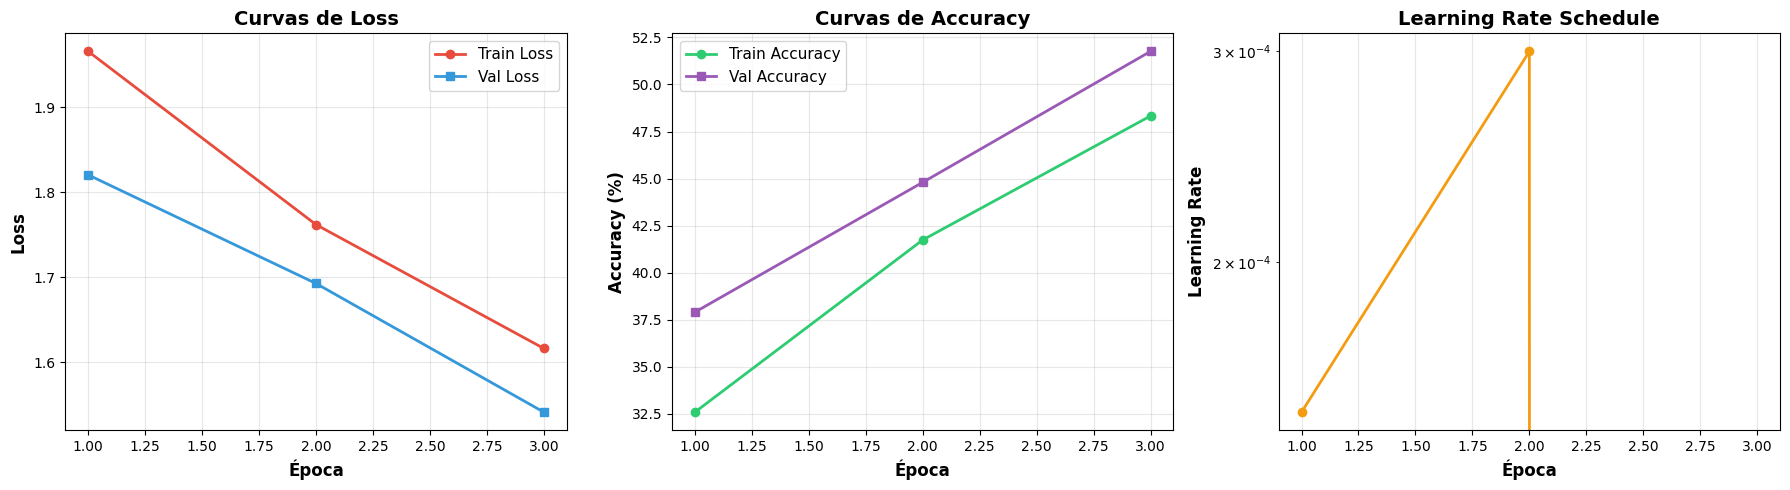

In [52]:
def plot_training_metrics(metrics: Dict[str, List[float]]) -> None:
    """
    Plota métricas de treinamento: loss e accuracy.
    
    Args:
        metrics: Dicionário com métricas
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    epochs = range(1, len(metrics['train_loss']) + 1)
    
    axes[0].plot(epochs, metrics['train_loss'], 'o-', label='Train Loss', 
                 linewidth=2, markersize=6, color='#e74c3c')
    axes[0].plot(epochs, metrics['val_loss'], 's-', label='Val Loss', 
                 linewidth=2, markersize=6, color='#3498db')
    axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0].set_title('Curvas de Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, metrics['train_acc'], 'o-', label='Train Accuracy', 
                 linewidth=2, markersize=6, color='#2ecc71')
    axes[1].plot(epochs, metrics['val_acc'], 's-', label='Val Accuracy', 
                 linewidth=2, markersize=6, color='#9b59b6')
    axes[1].set_xlabel('Época', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Curvas de Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(epochs, metrics['learning_rate'], 'o-', 
                 linewidth=2, markersize=6, color='#f39c12')
    axes[2].set_xlabel('Época', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

plot_training_metrics(performance_monitor.get_metrics())

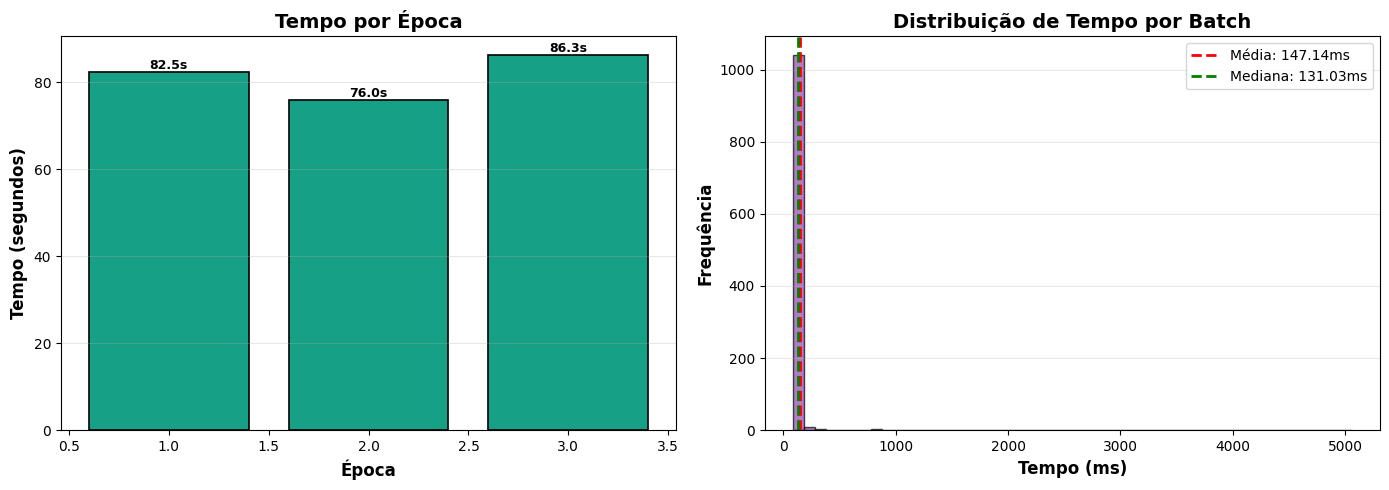

Estatísticas de Performance:
  Tempo médio por época: 81.60s
  Tempo médio por batch: 147.14ms
  Tempo mediano por batch: 131.03ms
  Throughput médio: 869.94 samples/s


In [53]:
def plot_performance_metrics(monitor: PerformanceMonitor) -> None:
    """
    Plota métricas de performance: tempo por época e tempo por batch.
    
    Args:
        monitor: Performance monitor
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epoch_times = monitor.epoch_times
    epochs = range(1, len(epoch_times) + 1)
    
    axes[0].bar(epochs, epoch_times, color='#16a085', edgecolor='black', linewidth=1.2)
    axes[0].set_xlabel('Época', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Tempo (segundos)', fontsize=12, fontweight='bold')
    axes[0].set_title('Tempo por Época', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    for i, time_val in enumerate(epoch_times):
        axes[0].text(i+1, time_val, f'{time_val:.1f}s', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    batch_times = monitor.batch_times
    axes[1].hist(batch_times, bins=50, color='#8e44ad', edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(batch_times), color='red', linestyle='--', 
                   linewidth=2, label=f'Média: {np.mean(batch_times):.2f}ms')
    axes[1].axvline(np.median(batch_times), color='green', linestyle='--', 
                   linewidth=2, label=f'Mediana: {np.median(batch_times):.2f}ms')
    axes[1].set_xlabel('Tempo (ms)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Frequência', fontsize=12, fontweight='bold')
    axes[1].set_title('Distribuição de Tempo por Batch', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Estatísticas de Performance:")
    print(f"  Tempo médio por época: {np.mean(epoch_times):.2f}s")
    print(f"  Tempo médio por batch: {np.mean(batch_times):.2f}ms")
    print(f"  Tempo mediano por batch: {np.median(batch_times):.2f}ms")
    print(f"  Throughput médio: {config.batch_size / (np.mean(batch_times)/1000):.2f} samples/s")

plot_performance_metrics(performance_monitor)

## 6. Avaliação Detalhada no Conjunto de Teste

In [54]:
def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    class_names: List[str]
) -> Dict[str, Any]:
    """
    Avaliação completa do modelo com todas as métricas.
    
    Args:
        model: Modelo treinado
        dataloader: DataLoader de teste
        device: Device
        class_names: Nomes das classes
        
    Returns:
        Dicionário com todas as métricas e predições
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_probabilities = []
    
    inference_times = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            
            start_time = time.time()
            outputs = model(images)
            inference_time = (time.time() - start_time) * 1000
            inference_times.append(inference_time)
            
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probabilities.extend(probabilities.cpu().numpy())
    
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_probabilities = np.array(all_probabilities)
    
    accuracy = accuracy_score(all_labels, all_predictions)
    
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_predictions, average=None, zero_division=0
    )
    
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='macro', zero_division=0
    )
    
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted', zero_division=0
    )
    
    conf_matrix = confusion_matrix(all_labels, all_predictions)
    
    cohen_kappa = cohen_kappa_score(all_labels, all_predictions)
    
    top5_correct = 0
    for i, probs in enumerate(all_probabilities):
        top5_preds = np.argsort(probs)[-5:]
        if all_labels[i] in top5_preds:
            top5_correct += 1
    top5_accuracy = top5_correct / len(all_labels)
    
    results = {
        'predictions': all_predictions,
        'labels': all_labels,
        'probabilities': all_probabilities,
        'accuracy': accuracy,
        'top5_accuracy': top5_accuracy,
        'precision_per_class': precision,
        'recall_per_class': recall,
        'f1_per_class': f1,
        'support_per_class': support,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'precision_weighted': precision_weighted,
        'recall_weighted': recall_weighted,
        'f1_weighted': f1_weighted,
        'confusion_matrix': conf_matrix,
        'cohen_kappa': cohen_kappa,
        'inference_times': inference_times,
        'avg_inference_time': np.mean(inference_times),
        'avg_inference_time_per_sample': np.mean(inference_times) / config.batch_size
    }
    
    return results

print("Avaliando modelo no conjunto de teste...")
test_results = evaluate_model(model, test_loader, device, CLASS_NAMES)

print("\nResultados no Conjunto de Teste:")
print("=" * 80)
print(f"Accuracy: {test_results['accuracy']*100:.2f}%")
print(f"Top-5 Accuracy: {test_results['top5_accuracy']*100:.2f}%")
print(f"\nMétricas Macro:")
print(f"  Precision: {test_results['precision_macro']*100:.2f}%")
print(f"  Recall: {test_results['recall_macro']*100:.2f}%")
print(f"  F1-Score: {test_results['f1_macro']*100:.2f}%")
print(f"\nMétricas Weighted:")
print(f"  Precision: {test_results['precision_weighted']*100:.2f}%")
print(f"  Recall: {test_results['recall_weighted']*100:.2f}%")
print(f"  F1-Score: {test_results['f1_weighted']*100:.2f}%")
print(f"\nCohen Kappa: {test_results['cohen_kappa']:.4f}")
print(f"\nPerformance de Inferência:")
print(f"  Tempo médio por batch: {test_results['avg_inference_time']:.2f}ms")
print(f"  Tempo médio por amostra: {test_results['avg_inference_time_per_sample']:.2f}ms")
print(f"  Throughput: {1000 / test_results['avg_inference_time_per_sample']:.2f} samples/s")
print("=" * 80)

Avaliando modelo no conjunto de teste...

Resultados no Conjunto de Teste:
Accuracy: 7.36%
Top-5 Accuracy: 49.22%

Métricas Macro:
  Precision: 10.74%
  Recall: 7.36%
  F1-Score: 6.90%

Métricas Weighted:
  Precision: 10.74%
  Recall: 7.36%
  F1-Score: 6.90%

Cohen Kappa: -0.0293

Performance de Inferência:
  Tempo médio por batch: 6.66ms
  Tempo médio por amostra: 0.05ms
  Throughput: 19213.68 samples/s


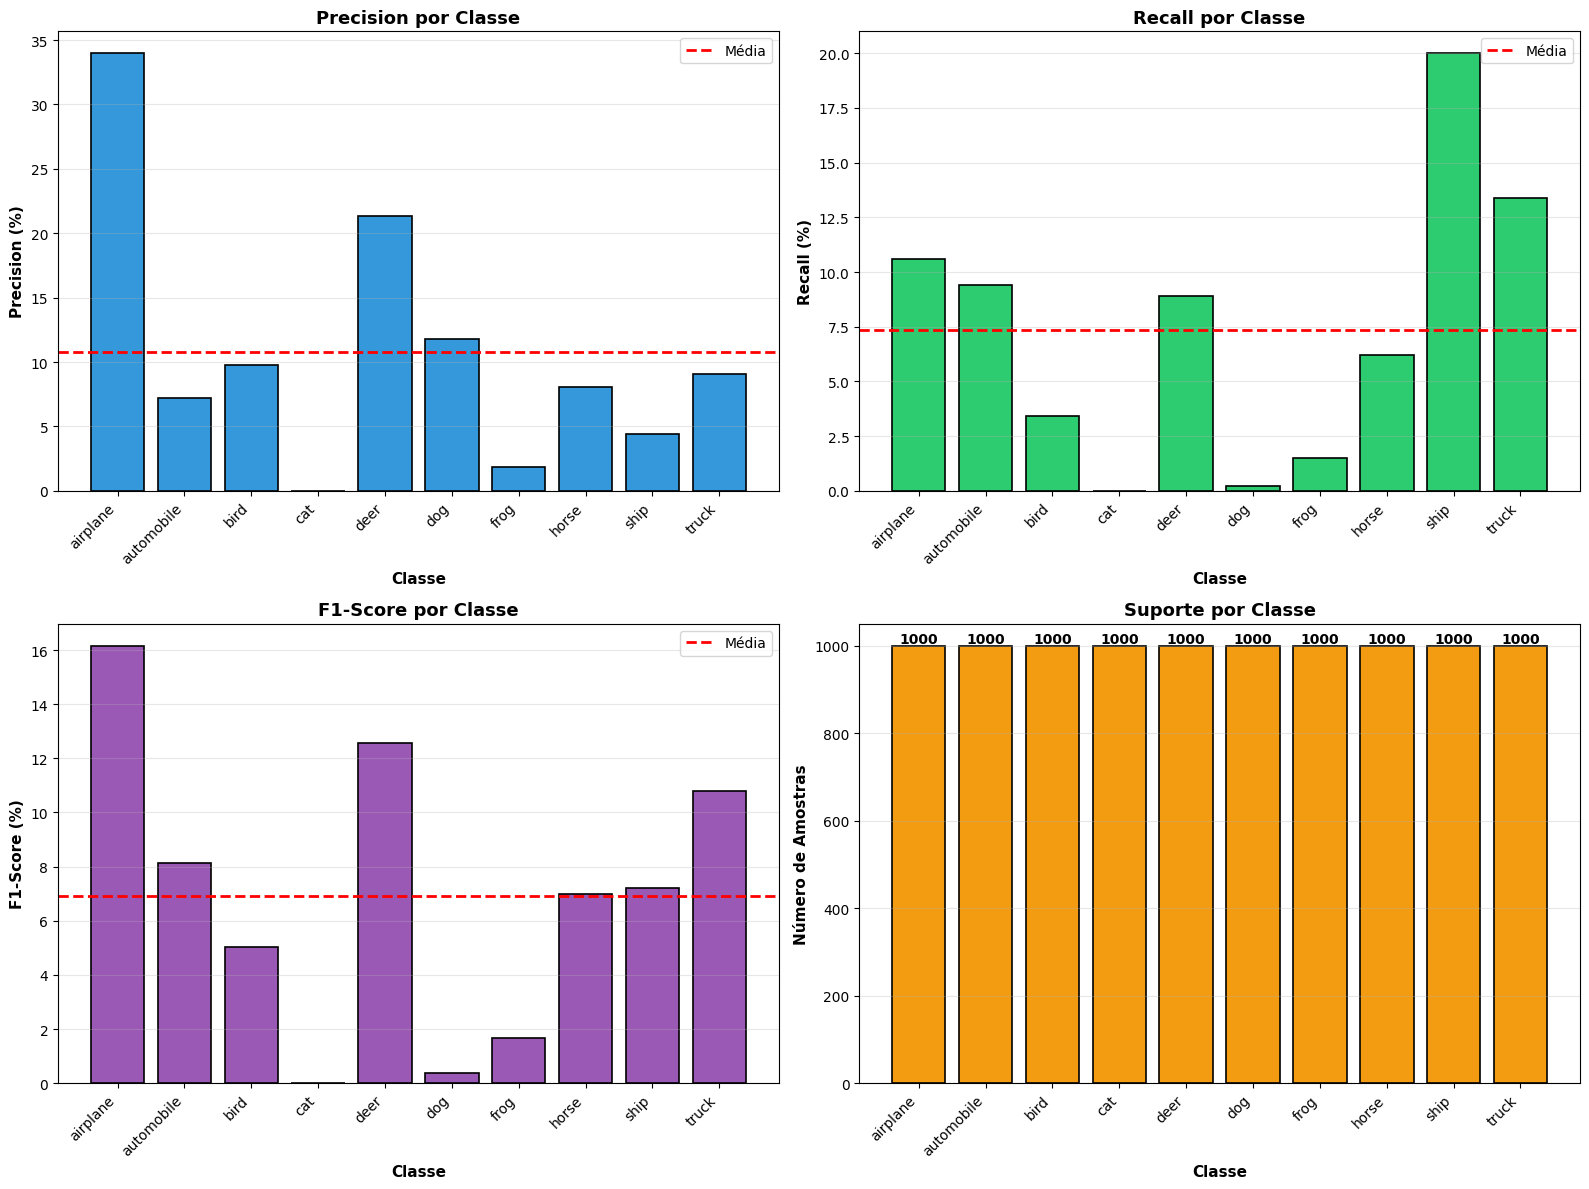

In [55]:
def plot_per_class_metrics(results: Dict[str, Any], class_names: List[str]) -> None:
    """
    Plota métricas por classe.
    
    Args:
        results: Dicionário de resultados
        class_names: Nomes das classes
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    x_pos = np.arange(len(class_names))
    
    axes[0, 0].bar(x_pos, results['precision_per_class'] * 100, 
                   color='#3498db', edgecolor='black', linewidth=1.2)
    axes[0, 0].set_xlabel('Classe', fontsize=11, fontweight='bold')
    axes[0, 0].set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
    axes[0, 0].set_title('Precision por Classe', fontsize=13, fontweight='bold')
    axes[0, 0].set_xticks(x_pos)
    axes[0, 0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].axhline(y=results['precision_macro']*100, color='red', 
                       linestyle='--', linewidth=2, label='Média')
    axes[0, 0].legend()
    
    axes[0, 1].bar(x_pos, results['recall_per_class'] * 100, 
                   color='#2ecc71', edgecolor='black', linewidth=1.2)
    axes[0, 1].set_xlabel('Classe', fontsize=11, fontweight='bold')
    axes[0, 1].set_ylabel('Recall (%)', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Recall por Classe', fontsize=13, fontweight='bold')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].axhline(y=results['recall_macro']*100, color='red', 
                       linestyle='--', linewidth=2, label='Média')
    axes[0, 1].legend()
    
    axes[1, 0].bar(x_pos, results['f1_per_class'] * 100, 
                   color='#9b59b6', edgecolor='black', linewidth=1.2)
    axes[1, 0].set_xlabel('Classe', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('F1-Score (%)', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('F1-Score por Classe', fontsize=13, fontweight='bold')
    axes[1, 0].set_xticks(x_pos)
    axes[1, 0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 0].grid(axis='y', alpha=0.3)
    axes[1, 0].axhline(y=results['f1_macro']*100, color='red', 
                       linestyle='--', linewidth=2, label='Média')
    axes[1, 0].legend()
    
    axes[1, 1].bar(x_pos, results['support_per_class'], 
                   color='#f39c12', edgecolor='black', linewidth=1.2)
    axes[1, 1].set_xlabel('Classe', fontsize=11, fontweight='bold')
    axes[1, 1].set_ylabel('Número de Amostras', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Suporte por Classe', fontsize=13, fontweight='bold')
    axes[1, 1].set_xticks(x_pos)
    axes[1, 1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1, 1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(results['support_per_class']):
        axes[1, 1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_per_class_metrics(test_results, CLASS_NAMES)

## 7. Matriz de Confusão

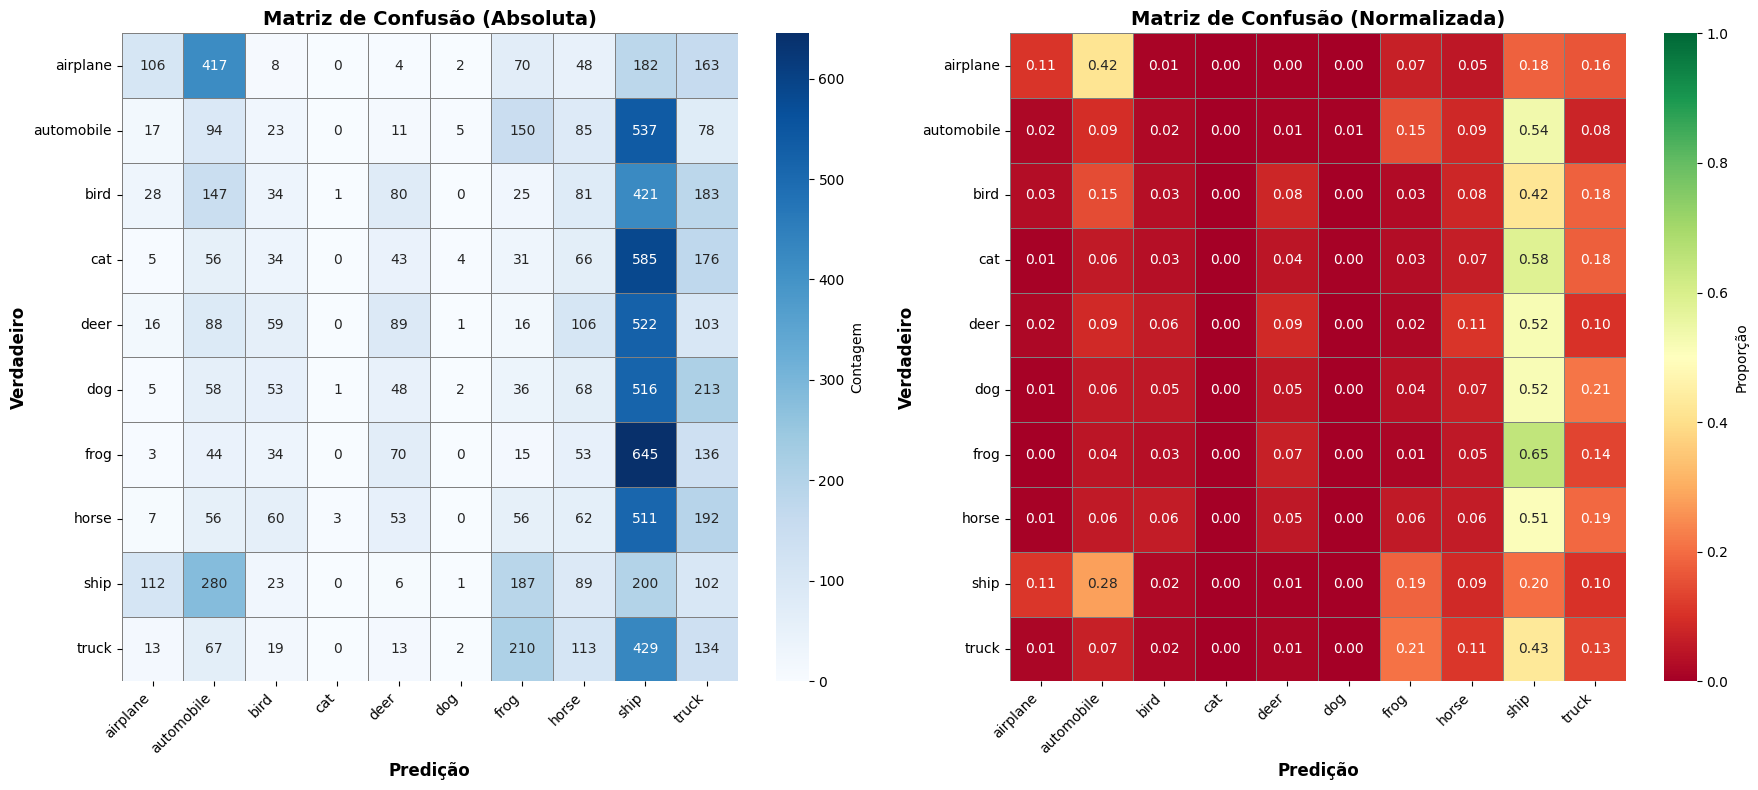


Análise da Matriz de Confusão:
  Predições corretas (diagonal): 736
  Total de predições: 10000
  Accuracy (da matriz): 7.36%


In [56]:
def plot_confusion_matrices(conf_matrix: np.ndarray, class_names: List[str]) -> None:
    """
    Plota matriz de confusão normalizada e absoluta.
    
    Args:
        conf_matrix: Matriz de confusão
        class_names: Nomes das classes
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Contagem'},
                linewidths=0.5, linecolor='gray')
    axes[0].set_xlabel('Predição', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Verdadeiro', fontsize=12, fontweight='bold')
    axes[0].set_title('Matriz de Confusão (Absoluta)', fontsize=14, fontweight='bold')
    axes[0].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0].set_yticklabels(class_names, rotation=0)
    
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2f', cmap='RdYlGn',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proporção'},
                linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
    axes[1].set_xlabel('Predição', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Verdadeiro', fontsize=12, fontweight='bold')
    axes[1].set_title('Matriz de Confusão (Normalizada)', fontsize=14, fontweight='bold')
    axes[1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[1].set_yticklabels(class_names, rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    diagonal_sum = np.trace(conf_matrix)
    total_sum = np.sum(conf_matrix)
    print(f"\nAnálise da Matriz de Confusão:")
    print(f"  Predições corretas (diagonal): {diagonal_sum}")
    print(f"  Total de predições: {total_sum}")
    print(f"  Accuracy (da matriz): {diagonal_sum/total_sum*100:.2f}%")

plot_confusion_matrices(test_results['confusion_matrix'], CLASS_NAMES)

## 8. Curvas ROC Multi-Classe

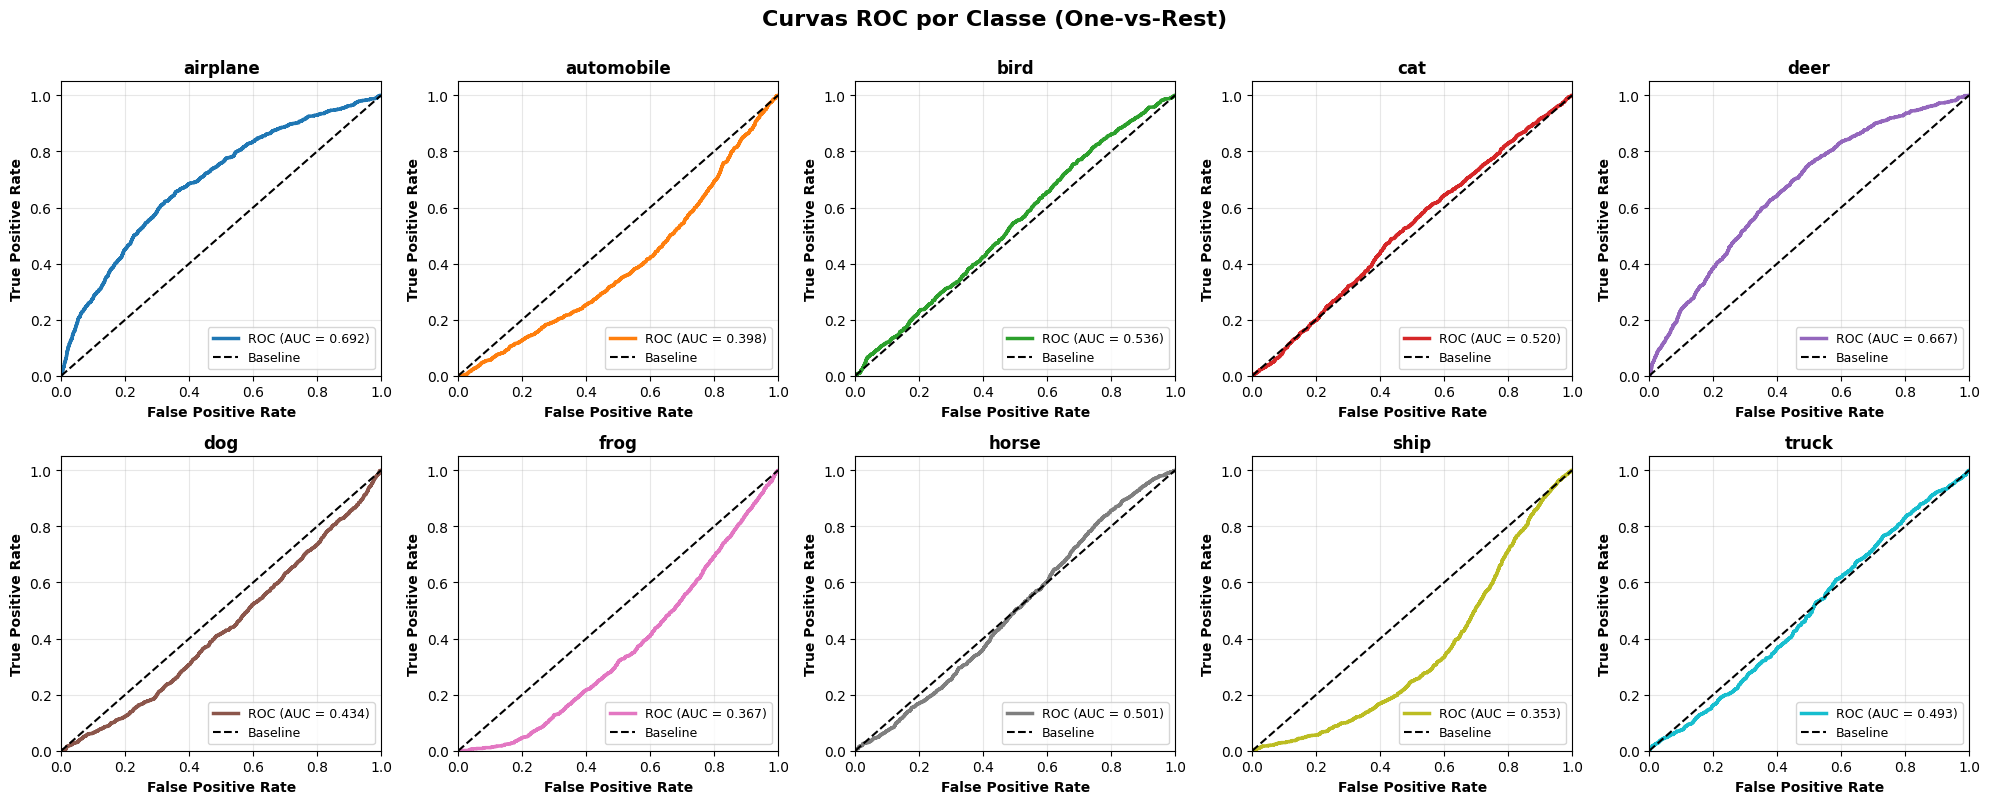


AUC-ROC por Classe:
  airplane    : 0.6918
  automobile  : 0.3982
  bird        : 0.5360
  cat         : 0.5197
  deer        : 0.6670
  dog         : 0.4343
  frog        : 0.3672
  horse       : 0.5014
  ship        : 0.3529
  truck       : 0.4934
  Média: 0.4962


In [57]:
def plot_roc_curves(results: Dict[str, Any], class_names: List[str]) -> None:
    """
    Plota curvas ROC para todas as classes (One-vs-Rest).
    
    Args:
        results: Dicionário de resultados
        class_names: Nomes das classes
    """
    n_classes = len(class_names)
    
    labels_onehot = np.zeros((len(results['labels']), n_classes))
    for i, label in enumerate(results['labels']):
        labels_onehot[i, label] = 1
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_onehot[:, i], results['probabilities'][:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    
    for i in range(n_classes):
        axes[i].plot(fpr[i], tpr[i], color=colors[i], linewidth=2.5,
                    label=f'ROC (AUC = {roc_auc[i]:.3f})')
        axes[i].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Baseline')
        axes[i].set_xlabel('False Positive Rate', fontsize=10, fontweight='bold')
        axes[i].set_ylabel('True Positive Rate', fontsize=10, fontweight='bold')
        axes[i].set_title(f'{class_names[i]}', fontsize=12, fontweight='bold')
        axes[i].legend(loc='lower right', fontsize=9)
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
    
    plt.suptitle('Curvas ROC por Classe (One-vs-Rest)', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAUC-ROC por Classe:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name:12s}: {roc_auc[i]:.4f}")
    print(f"  Média: {np.mean(list(roc_auc.values())):.4f}")

plot_roc_curves(test_results, CLASS_NAMES)

## 9. Análise de Embeddings

### 9.1 Extração de Embeddings

In [58]:
def extract_embeddings(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
    max_samples: int = 2000
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extrai embeddings (class token) do modelo.
    
    Args:
        model: Modelo treinado
        dataloader: DataLoader
        device: Device
        max_samples: Número máximo de amostras
        
    Returns:
        (embeddings, labels)
    """
    model.eval()
    
    embeddings_list = []
    labels_list = []
    
    total_collected = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            if total_collected >= max_samples:
                break
            
            images = images.to(device)
            
            batch_size = images.shape[0]
            x = model.patch_embedding(images)
            class_tokens = model.class_token.expand(batch_size, -1, -1)
            x = torch.cat([class_tokens, x], dim=1)
            x = x + model.position_embedding
            x = model.dropout(x)
            
            for block in model.transformer_blocks:
                x = block(x)
            
            x = model.norm(x)
            class_token_output = x[:, 0]
            
            embeddings_list.append(class_token_output.cpu().numpy())
            labels_list.append(labels.numpy())
            
            total_collected += batch_size
    
    embeddings = np.concatenate(embeddings_list, axis=0)[:max_samples]
    labels = np.concatenate(labels_list, axis=0)[:max_samples]
    
    return embeddings, labels

print("Extraindo embeddings do conjunto de teste...")
embeddings, embedding_labels = extract_embeddings(model, test_loader, device, max_samples=2000)
print(f"Embeddings extraídos: {embeddings.shape}")
print(f"  Dimensão: {embeddings.shape[1]}")
print(f"  Amostras: {embeddings.shape[0]}")

Extraindo embeddings do conjunto de teste...
Embeddings extraídos: (2000, 256)
  Dimensão: 256
  Amostras: 2000


### 9.2 Visualização t-SNE

Calculando t-SNE (perplexity=30)...


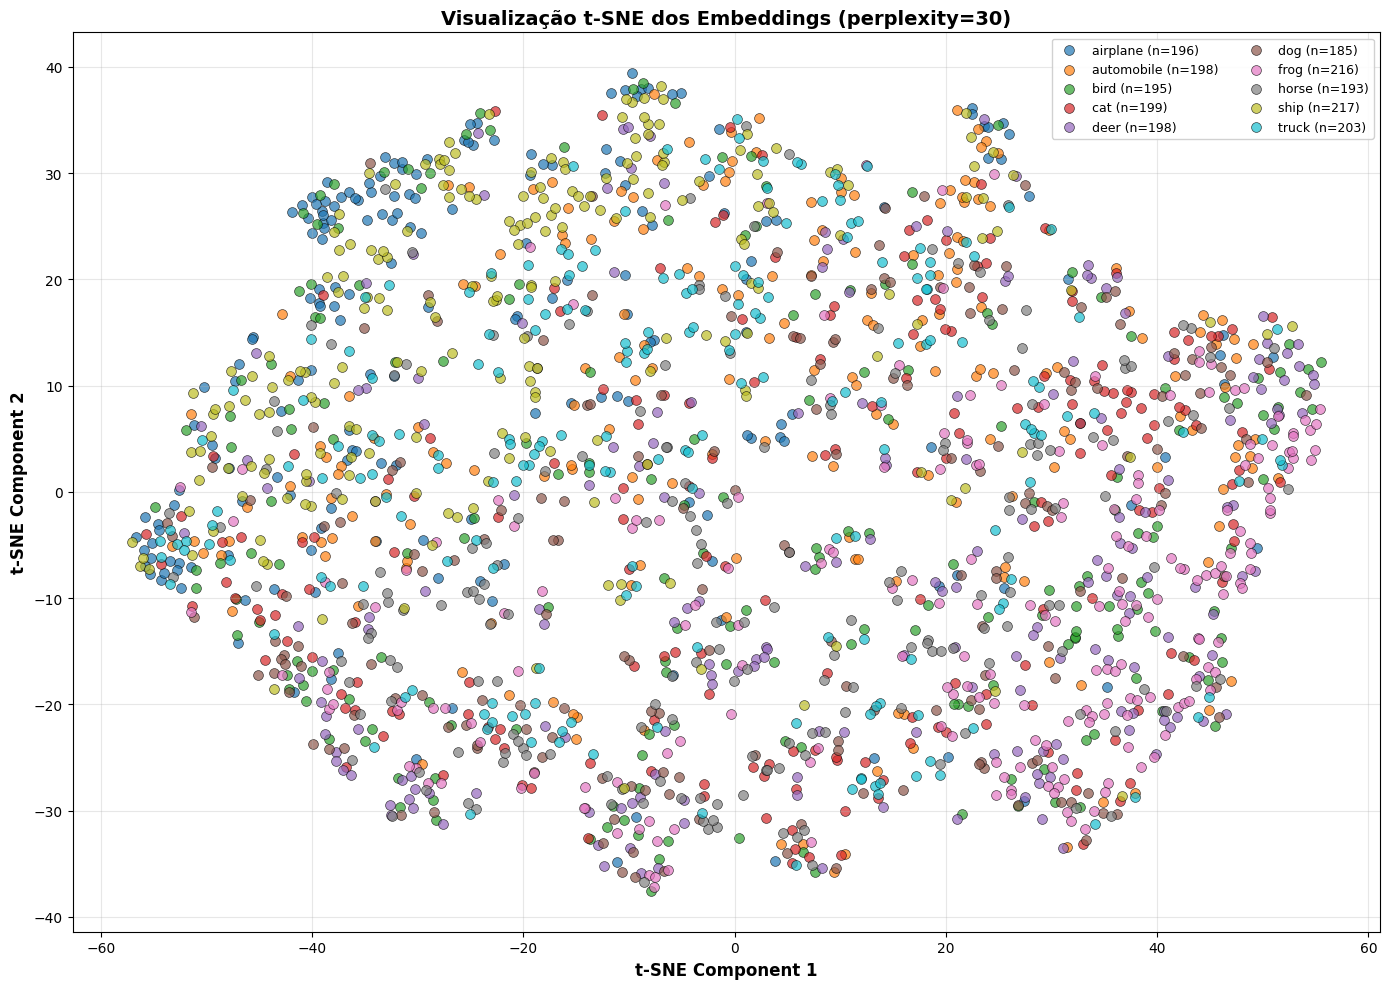

In [59]:
def plot_tsne(
    embeddings: np.ndarray,
    labels: np.ndarray,
    class_names: List[str],
    perplexity: int = 30
) -> None:
    """
    Visualiza embeddings usando t-SNE.
    
    Args:
        embeddings: Array (N, embedding_dim)
        labels: Array (N,)
        class_names: Nomes das classes
        perplexity: Perplexidade do t-SNE
    """
    print(f"Calculando t-SNE (perplexity={perplexity})...")
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, max_iter=1000)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for i, class_name in enumerate(class_names):
        mask = labels == i
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=f'{class_name} (n={mask.sum()})',
            alpha=0.7,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    ax.set_xlabel('t-SNE Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('t-SNE Component 2', fontsize=12, fontweight='bold')
    ax.set_title(f'Visualização t-SNE dos Embeddings (perplexity={perplexity})', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_tsne(embeddings, embedding_labels, CLASS_NAMES, perplexity=30)

### 9.3 Visualização UMAP

Calculando UMAP (n_neighbors=15, min_dist=0.1)...


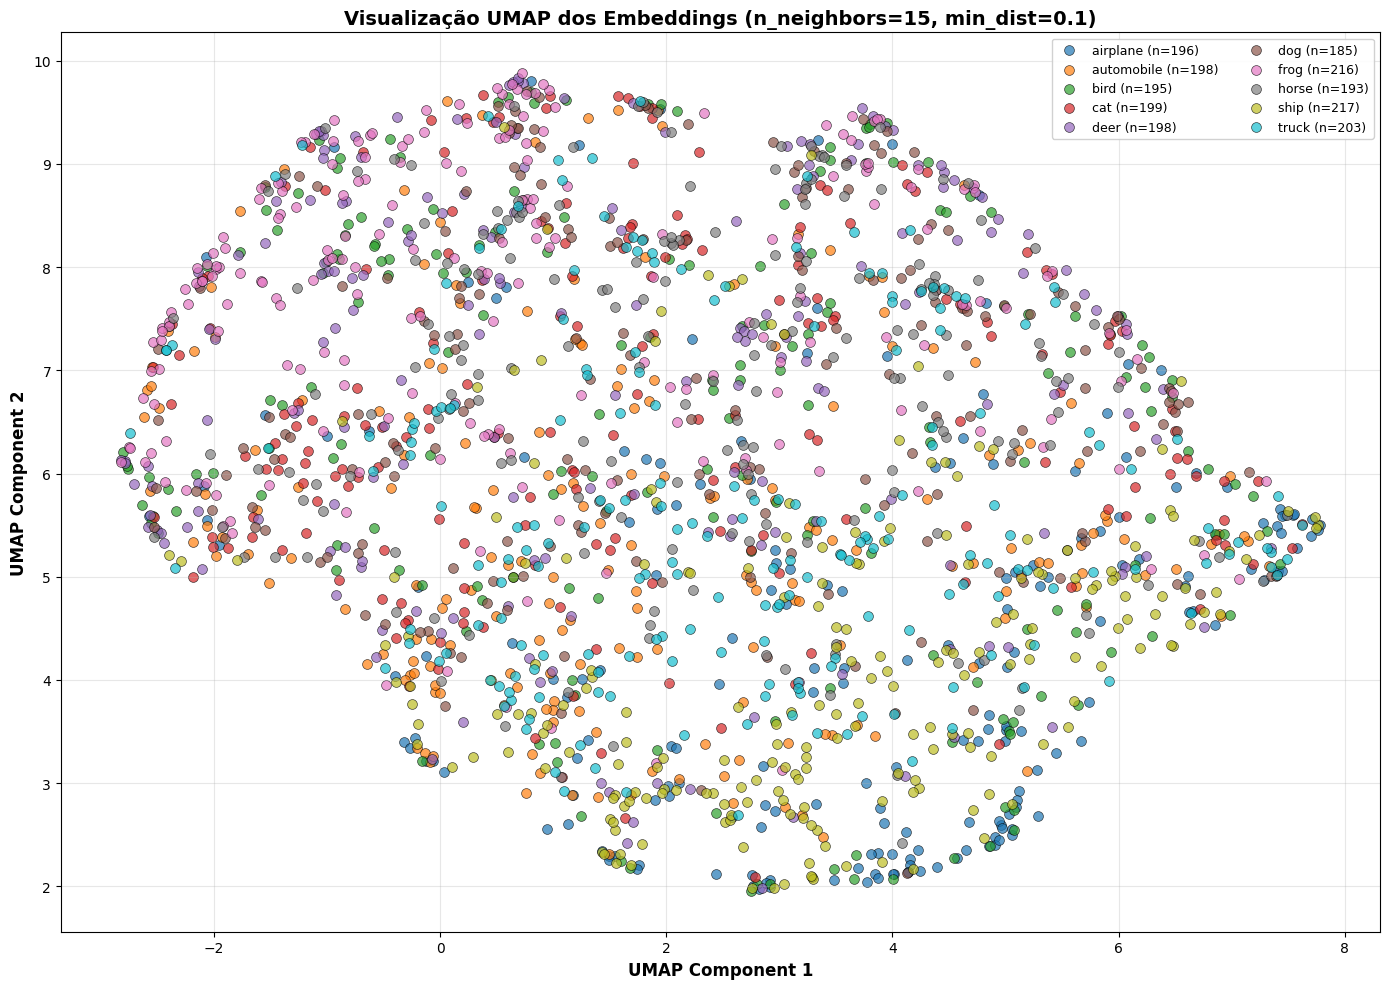

In [60]:
def plot_umap(
    embeddings: np.ndarray,
    labels: np.ndarray,
    class_names: List[str],
    n_neighbors: int = 15,
    min_dist: float = 0.1
) -> None:
    """
    Visualiza embeddings usando UMAP.
    
    Args:
        embeddings: Array (N, embedding_dim)
        labels: Array (N,)
        class_names: Nomes das classes
        n_neighbors: Número de vizinhos
        min_dist: Distância mínima
    """
    print(f"Calculando UMAP (n_neighbors={n_neighbors}, min_dist={min_dist})...")
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=SEED)
    embeddings_2d = reducer.fit_transform(embeddings)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for i, class_name in enumerate(class_names):
        mask = labels == i
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=f'{class_name} (n={mask.sum()})',
            alpha=0.7,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    ax.set_xlabel('UMAP Component 1', fontsize=12, fontweight='bold')
    ax.set_ylabel('UMAP Component 2', fontsize=12, fontweight='bold')
    ax.set_title(f'Visualização UMAP dos Embeddings (n_neighbors={n_neighbors}, min_dist={min_dist})', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_umap(embeddings, embedding_labels, CLASS_NAMES, n_neighbors=15, min_dist=0.1)

### 9.4 Análise PCA

Calculando PCA (n_components=50)...


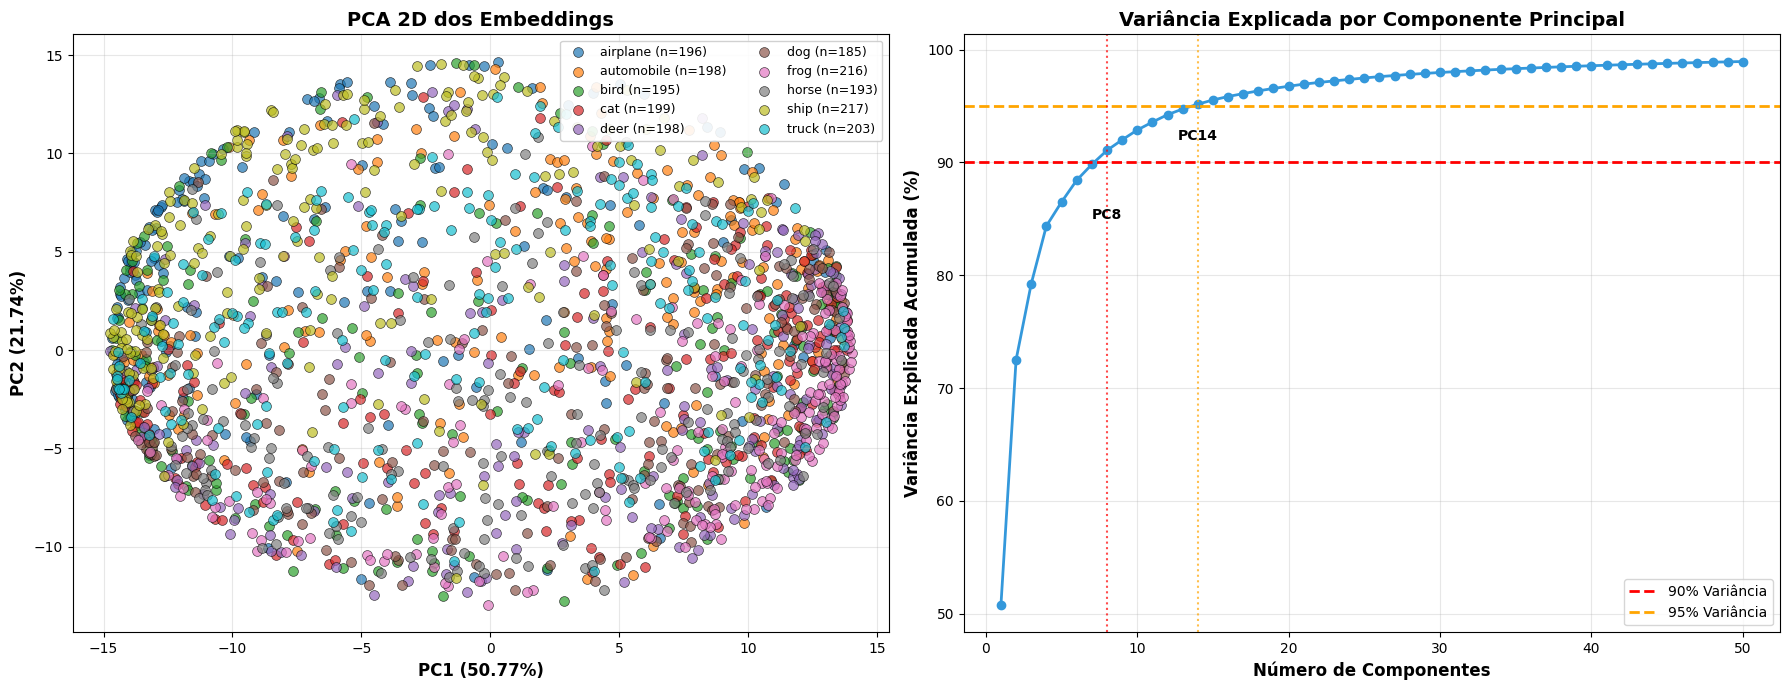


Análise PCA:
  Primeiras 2 componentes explicam: 72.51%
  8 componentes explicam 90% da variância
  14 componentes explicam 95% da variância
  Total de componentes analisados: 50


In [61]:
def plot_pca_analysis(
    embeddings: np.ndarray,
    labels: np.ndarray,
    class_names: List[str],
    n_components: int = 50
) -> None:
    """
    Análise PCA com visualização 2D e variância explicada.
    
    Args:
        embeddings: Array (N, embedding_dim)
        labels: Array (N,)
        class_names: Nomes das classes
        n_components: Número de componentes
    """
    print(f"Calculando PCA (n_components={n_components})...")
    pca = PCA(n_components=n_components, random_state=SEED)
    embeddings_pca = pca.fit_transform(embeddings)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for i, class_name in enumerate(class_names):
        mask = labels == i
        axes[0].scatter(
            embeddings_pca[mask, 0],
            embeddings_pca[mask, 1],
            c=[colors[i]],
            label=f'{class_name} (n={mask.sum()})',
            alpha=0.7,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', 
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', 
                      fontsize=12, fontweight='bold')
    axes[0].set_title('PCA 2D dos Embeddings', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
    axes[0].grid(True, alpha=0.3)
    
    cumsum_variance = np.cumsum(pca.explained_variance_ratio_)
    
    axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance * 100, 
                'o-', linewidth=2, markersize=6, color='#3498db')
    axes[1].axhline(y=90, color='red', linestyle='--', linewidth=2, label='90% Variância')
    axes[1].axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Variância')
    
    n_90 = np.argmax(cumsum_variance >= 0.90) + 1
    n_95 = np.argmax(cumsum_variance >= 0.95) + 1
    
    axes[1].axvline(x=n_90, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    axes[1].axvline(x=n_95, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
    
    axes[1].text(n_90, 85, f'PC{n_90}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(n_95, 92, f'PC{n_95}', ha='center', fontsize=10, fontweight='bold')
    
    axes[1].set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Variância Explicada Acumulada (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('Variância Explicada por Componente Principal', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nAnálise PCA:")
    print(f"  Primeiras 2 componentes explicam: {cumsum_variance[1]*100:.2f}%")
    print(f"  {n_90} componentes explicam 90% da variância")
    print(f"  {n_95} componentes explicam 95% da variância")
    print(f"  Total de componentes analisados: {n_components}")

plot_pca_analysis(embeddings, embedding_labels, CLASS_NAMES, n_components=50)

### 9.5 Heatmap de Similaridade entre Classes

## 10. Visualização da Projeção Linear (Classificador)

Análise dos pesos da última camada linear que realiza a classificação.

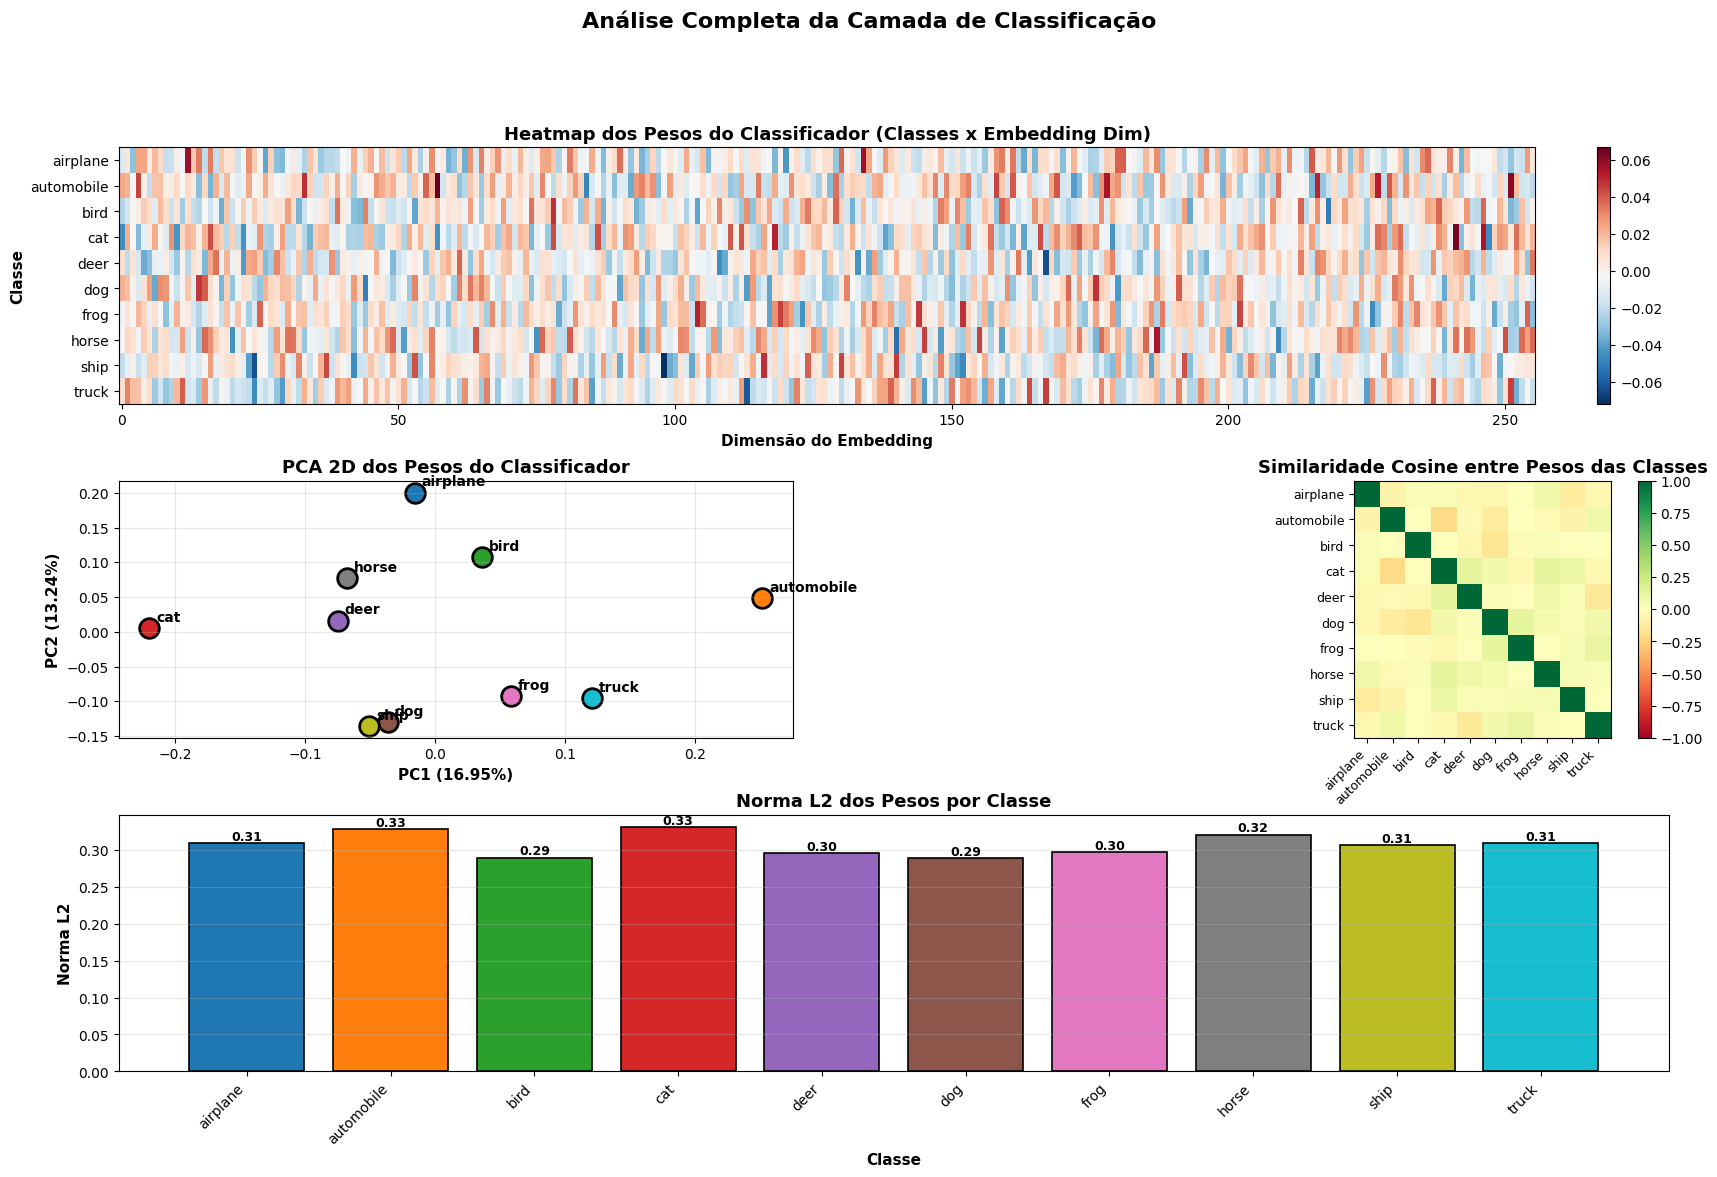


Estatísticas dos Pesos do Classificador:
  Shape: (10, 256)
  Mean: 0.000129
  Std: 0.019274
  Min: -0.071705
  Max: 0.066850

Norma L2 por classe:
  airplane    : 0.3092
  automobile  : 0.3287
  bird        : 0.2902
  cat         : 0.3318
  deer        : 0.2960
  dog         : 0.2893
  frog        : 0.2975
  horse       : 0.3213
  ship        : 0.3071
  truck       : 0.3094


In [62]:
def visualize_classifier_weights(model: VisionTransformer, class_names: List[str]) -> None:
    """
    Visualiza os pesos da camada de classificação.
    
    Análises:
    1. Heatmap dos pesos (classes x embedding_dim)
    2. PCA 2D dos vetores de peso por classe
    3. Similaridade cosine entre classes
    4. Norma L2 dos pesos por classe
    
    Args:
        model: Modelo treinado
        class_names: Nomes das classes
    """
    classifier_weights = model.classifier.weight.detach().cpu().numpy()
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0, :])
    im1 = ax1.imshow(classifier_weights, cmap='RdBu_r', aspect='auto')
    ax1.set_xlabel('Dimensão do Embedding', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Classe', fontsize=11, fontweight='bold')
    ax1.set_yticks(range(len(class_names)))
    ax1.set_yticklabels(class_names)
    ax1.set_title('Heatmap dos Pesos do Classificador (Classes x Embedding Dim)', 
                  fontsize=13, fontweight='bold')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    pca = PCA(n_components=2, random_state=SEED)
    weights_pca = pca.fit_transform(classifier_weights)
    
    ax2 = fig.add_subplot(gs[1, 0])
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
    
    for i, class_name in enumerate(class_names):
        ax2.scatter(weights_pca[i, 0], weights_pca[i, 1], 
                   c=[colors[i]], s=200, edgecolors='black', linewidth=2)
        ax2.annotate(class_name, (weights_pca[i, 0], weights_pca[i, 1]),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)', 
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)', 
                  fontsize=11, fontweight='bold')
    ax2.set_title('PCA 2D dos Pesos do Classificador', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    from sklearn.metrics.pairwise import cosine_similarity
    similarity_matrix = cosine_similarity(classifier_weights)
    
    ax3 = fig.add_subplot(gs[1, 1])
    im3 = ax3.imshow(similarity_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
    ax3.set_xticks(range(len(class_names)))
    ax3.set_yticks(range(len(class_names)))
    ax3.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax3.set_yticklabels(class_names, fontsize=9)
    ax3.set_title('Similaridade Cosine entre Pesos das Classes', fontsize=13, fontweight='bold')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    norms = np.linalg.norm(classifier_weights, axis=1)
    
    ax4 = fig.add_subplot(gs[2, :])
    bars = ax4.bar(class_names, norms, color=colors, edgecolor='black', linewidth=1.2)
    ax4.set_xlabel('Classe', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Norma L2', fontsize=11, fontweight='bold')
    ax4.set_title('Norma L2 dos Pesos por Classe', fontsize=13, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    
    for bar, norm in zip(bars, norms):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{norm:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    plt.suptitle('Análise Completa da Camada de Classificação', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.show()
    
    print(f"\nEstatísticas dos Pesos do Classificador:")
    print(f"  Shape: {classifier_weights.shape}")
    print(f"  Mean: {classifier_weights.mean():.6f}")
    print(f"  Std: {classifier_weights.std():.6f}")
    print(f"  Min: {classifier_weights.min():.6f}")
    print(f"  Max: {classifier_weights.max():.6f}")
    print(f"\nNorma L2 por classe:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name:12s}: {norms[i]:.4f}")

visualize_classifier_weights(model, CLASS_NAMES)

## 11. Visualização de Attention Maps

Análise dos padrões de atenção aprendidos pelo modelo.

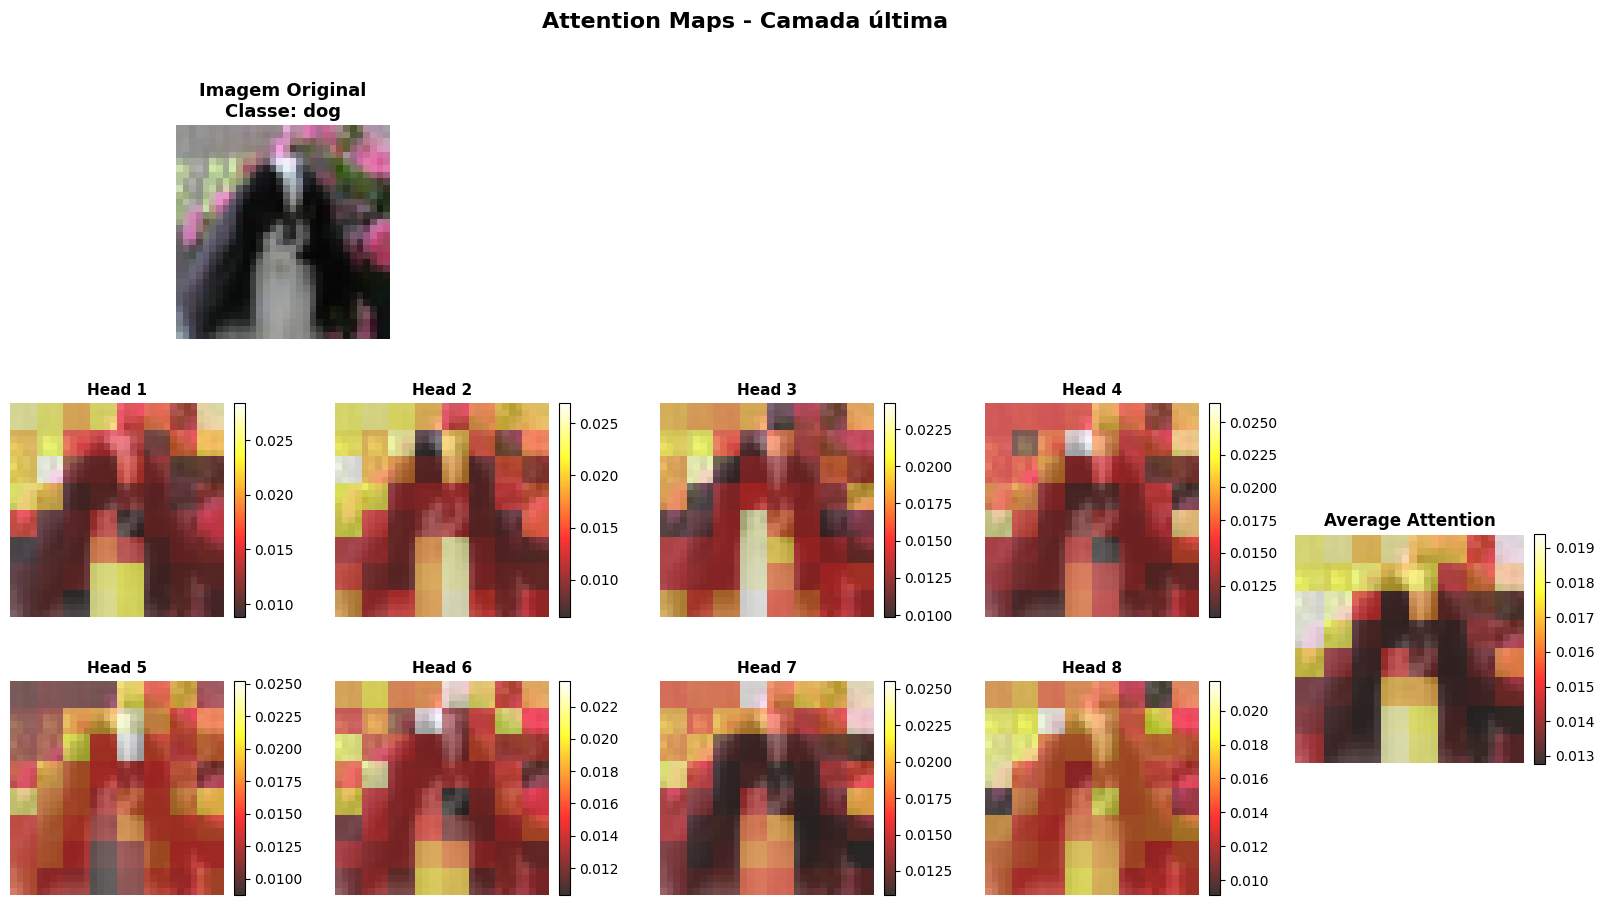

In [63]:
def visualize_attention_maps(
    model: VisionTransformer,
    image: torch.Tensor,
    class_name: str,
    layer_idx: int = -1
) -> None:
    """
    Visualiza attention maps de todas as heads em uma camada.
    
    Args:
        model: Modelo treinado
        image: Tensor (C, H, W) normalizado
        class_name: Nome da classe
        layer_idx: Índice da camada (-1 para última)
    """
    model.eval()
    
    img_denorm = image.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img_denorm = img_denorm * std + mean
    img_denorm = np.clip(img_denorm, 0, 1)
    
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)
        attention_weights = model.get_attention_maps(image_batch, layer_idx=layer_idx)
    
    attention_weights = attention_weights.squeeze(0).cpu().numpy()
    num_heads = attention_weights.shape[0]
    
    class_token_attention = attention_weights[:, 0, 1:]
    
    patch_size = config.patch_size
    num_patches_per_side = config.image_size[0] // patch_size
    
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(3, num_heads // 2 + 1, hspace=0.3, wspace=0.3)
    
    ax_img = fig.add_subplot(gs[0, :2])
    ax_img.imshow(img_denorm)
    ax_img.set_title(f'Imagem Original\nClasse: {class_name}', 
                     fontsize=13, fontweight='bold')
    ax_img.axis('off')
    
    for i in range(num_heads):
        row = 1 + (i // (num_heads // 2))
        col = i % (num_heads // 2)
        
        ax = fig.add_subplot(gs[row, col])
        
        attention_map = class_token_attention[i].reshape(num_patches_per_side, num_patches_per_side)
        
        attention_resized = np.kron(attention_map, np.ones((patch_size, patch_size)))
        
        im = ax.imshow(attention_resized, cmap='hot', alpha=0.8)
        ax.imshow(img_denorm, alpha=0.4)
        ax.set_title(f'Head {i+1}', fontsize=11, fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    avg_attention = class_token_attention.mean(axis=0).reshape(num_patches_per_side, num_patches_per_side)
    avg_attention_resized = np.kron(avg_attention, np.ones((patch_size, patch_size)))
    
    ax_avg = fig.add_subplot(gs[1:, -1])
    im_avg = ax_avg.imshow(avg_attention_resized, cmap='hot', alpha=0.8)
    ax_avg.imshow(img_denorm, alpha=0.4)
    ax_avg.set_title('Average Attention', fontsize=12, fontweight='bold')
    ax_avg.axis('off')
    plt.colorbar(im_avg, ax=ax_avg, fraction=0.046, pad=0.04)
    
    layer_name = 'última' if layer_idx == -1 else f'{layer_idx+1}'
    plt.suptitle(f'Attention Maps - Camada {layer_name}', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.show()

sample_idx = 42
sample_img, sample_label = test_dataset[sample_idx]
visualize_attention_maps(model, sample_img, CLASS_NAMES[sample_label], layer_idx=-1)

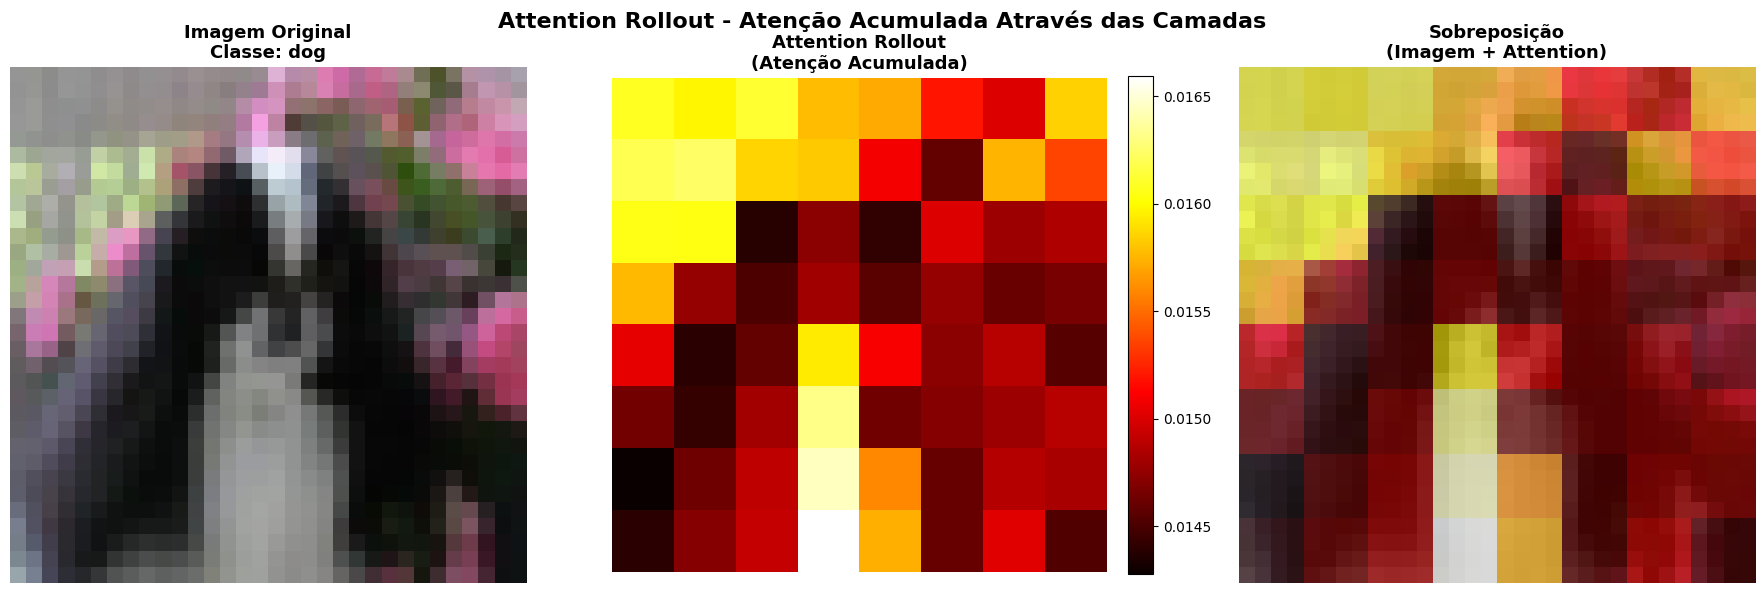

In [64]:
def compute_attention_rollout(
    model: VisionTransformer,
    image: torch.Tensor
) -> np.ndarray:
    """
    Calcula attention rollout acumulado através das camadas.
    
    Args:
        model: Modelo treinado
        image: Tensor (C, H, W)
        
    Returns:
        Attention rollout (num_patches,)
    """
    model.eval()
    
    with torch.no_grad():
        batch_size = 1
        image_batch = image.unsqueeze(0).to(device)
        
        x = model.patch_embedding(image_batch)
        class_tokens = model.class_token.expand(batch_size, -1, -1)
        x = torch.cat([class_tokens, x], dim=1)
        x = x + model.position_embedding
        x = model.dropout(x)
        
        attentions = []
        for block in model.transformer_blocks:
            x = x + block.attention(block.norm1(x))
            attention_weights = block.attention.attention_weights
            attentions.append(attention_weights.cpu().numpy())
            x = x + block.mlp(block.norm2(x))
    
    num_layers = len(attentions)
    num_heads = attentions[0].shape[1]
    seq_len = attentions[0].shape[2]
    
    rollout = np.eye(seq_len)
    
    for attention in attentions:
        attention_avg = attention[0].mean(axis=0)
        
        attention_avg = attention_avg + np.eye(seq_len)
        attention_avg = attention_avg / attention_avg.sum(axis=-1, keepdims=True)
        
        rollout = np.matmul(attention_avg, rollout)
    
    class_token_attention = rollout[0, 1:]
    
    return class_token_attention


def visualize_attention_rollout(
    model: VisionTransformer,
    image: torch.Tensor,
    class_name: str
) -> None:
    """
    Visualiza attention rollout acumulado.
    
    Args:
        model: Modelo treinado
        image: Tensor (C, H, W)
        class_name: Nome da classe
    """
    img_denorm = image.numpy().transpose(1, 2, 0)
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    img_denorm = img_denorm * std + mean
    img_denorm = np.clip(img_denorm, 0, 1)
    
    attention_rollout = compute_attention_rollout(model, image)
    
    patch_size = config.patch_size
    num_patches_per_side = config.image_size[0] // patch_size
    
    attention_map = attention_rollout.reshape(num_patches_per_side, num_patches_per_side)
    attention_resized = np.kron(attention_map, np.ones((patch_size, patch_size)))
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_denorm)
    axes[0].set_title(f'Imagem Original\nClasse: {class_name}', 
                     fontsize=13, fontweight='bold')
    axes[0].axis('off')
    
    im1 = axes[1].imshow(attention_resized, cmap='hot')
    axes[1].set_title('Attention Rollout\n(Atenção Acumulada)', 
                     fontsize=13, fontweight='bold')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    axes[2].imshow(img_denorm)
    axes[2].imshow(attention_resized, cmap='hot', alpha=0.6)
    axes[2].set_title('Sobreposição\n(Imagem + Attention)', 
                     fontsize=13, fontweight='bold')
    axes[2].axis('off')
    
    plt.suptitle('Attention Rollout - Atenção Acumulada Através das Camadas', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_attention_rollout(model, sample_img, CLASS_NAMES[sample_label])

## 12. Análise de Predições

Visualização de predições corretas e incorretas.

Visualizando predições corretas:


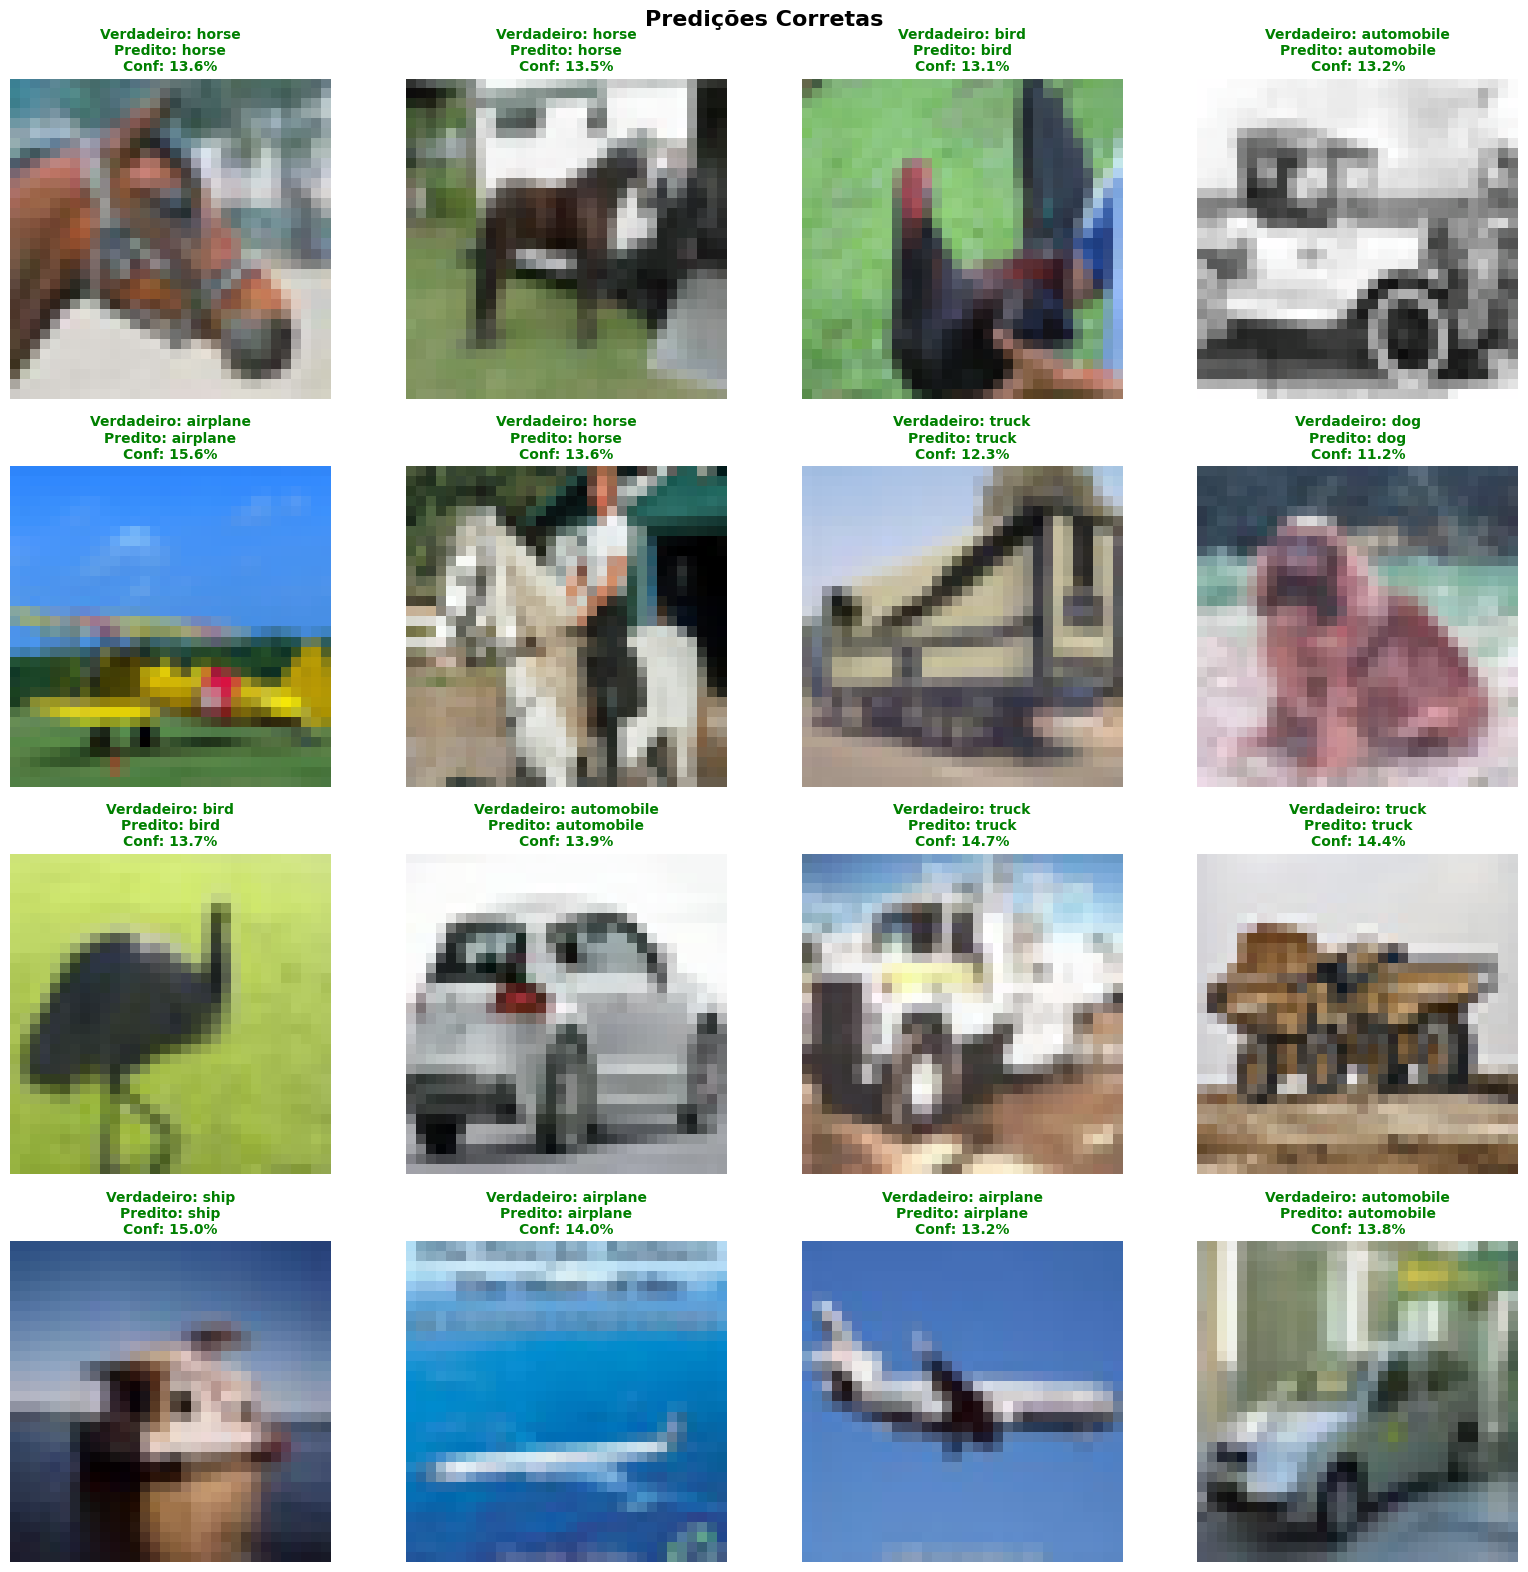

In [65]:
def visualize_predictions(
    model: VisionTransformer,
    dataset: datasets.CIFAR10,
    class_names: List[str],
    num_samples: int = 16,
    correct: bool = True
) -> None:
    """
    Visualiza predições corretas ou incorretas.
    
    Args:
        model: Modelo treinado
        dataset: Dataset
        class_names: Nomes das classes
        num_samples: Número de amostras
        correct: Se True, mostra corretas; se False, incorretas
    """
    model.eval()
    
    samples = []
    idx = 0
    
    with torch.no_grad():
        while len(samples) < num_samples and idx < len(dataset):
            image, label = dataset[idx]
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            _, predicted = output.max(1)
            predicted = predicted.item()
            
            is_correct = (predicted == label)
            
            if (correct and is_correct) or (not correct and not is_correct):
                probabilities = F.softmax(output, dim=1).cpu().numpy()[0]
                samples.append({
                    'image': image,
                    'label': label,
                    'predicted': predicted,
                    'probabilities': probabilities
                })
            
            idx += 1
    
    num_cols = 4
    num_rows = (num_samples + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, num_rows * 4))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for i, sample in enumerate(samples):
        ax = axes[i]
        
        img_denorm = sample['image'].numpy().transpose(1, 2, 0)
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img_denorm = img_denorm * std + mean
        img_denorm = np.clip(img_denorm, 0, 1)
        
        ax.imshow(img_denorm)
        
        true_label = class_names[sample['label']]
        pred_label = class_names[sample['predicted']]
        confidence = sample['probabilities'][sample['predicted']] * 100
        
        if correct:
            title_color = 'green'
            title = f"Verdadeiro: {true_label}\nPredito: {pred_label}\nConf: {confidence:.1f}%"
        else:
            title_color = 'red'
            title = f"Verdadeiro: {true_label}\nPredito: {pred_label}\nConf: {confidence:.1f}%"
        
        ax.set_title(title, fontsize=10, fontweight='bold', color=title_color)
        ax.axis('off')
    
    for i in range(len(samples), len(axes)):
        axes[i].axis('off')
    
    status = "Corretas" if correct else "Incorretas"
    plt.suptitle(f'Predições {status}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("Visualizando predições corretas:")
visualize_predictions(model, test_dataset, CLASS_NAMES, num_samples=16, correct=True)

Visualizando predições incorretas:


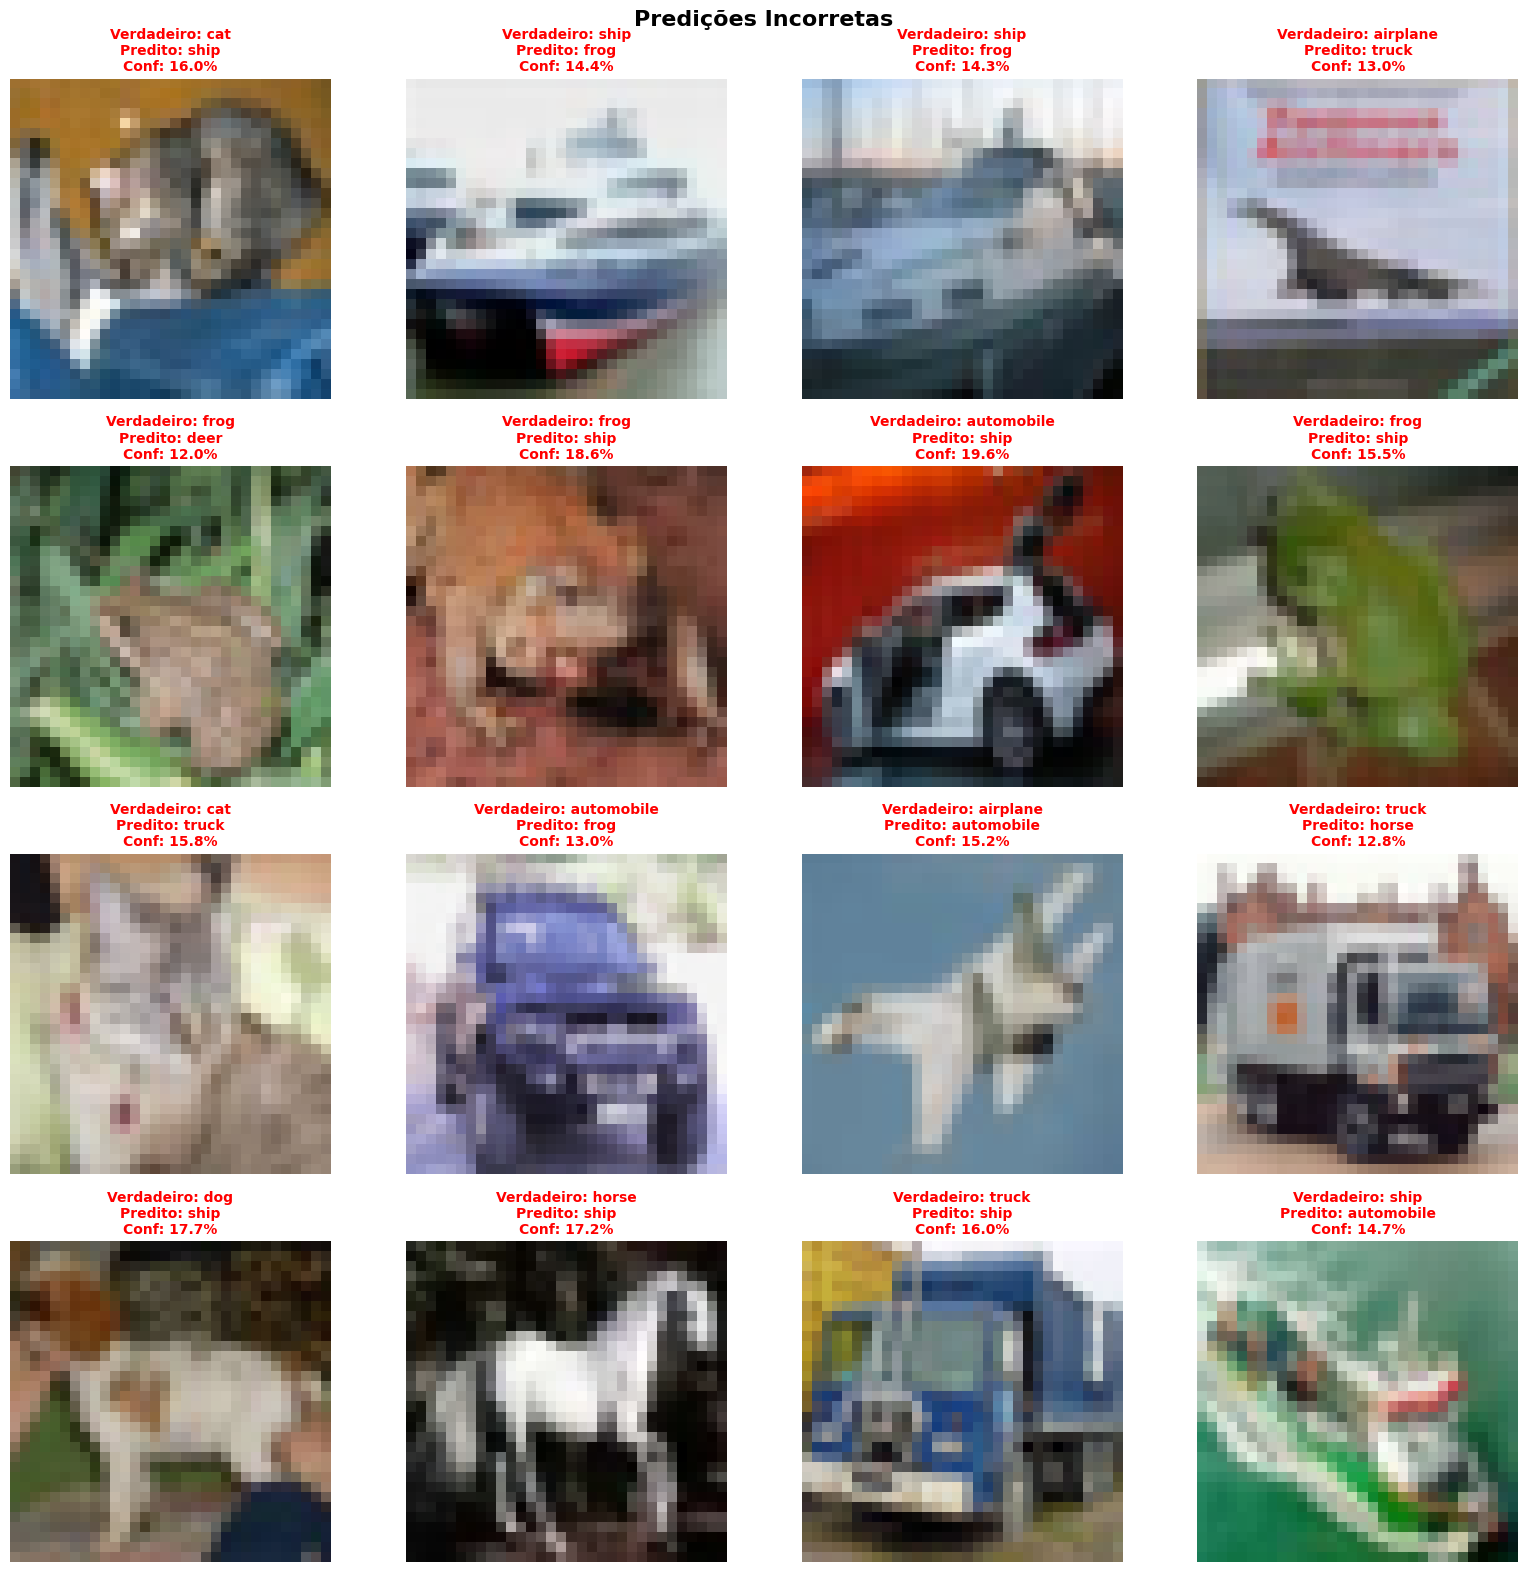

In [66]:
print("Visualizando predições incorretas:")
visualize_predictions(model, test_dataset, CLASS_NAMES, num_samples=16, correct=False)

## 13. Salvamento do Modelo

In [ ]:
save_path = Path('./vity_cifar10_model.pth')

torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'test_accuracy': test_results['accuracy'],
    'test_results': test_results,
    'class_names': CLASS_NAMES
}, save_path)

print(f"Modelo salvo em: {save_path.absolute()}")
print(f"Tamanho do arquivo: {save_path.stat().st_size / 1024**2:.2f} MB")

print("\nPara carregar o modelo:")
print("  checkpoint = torch.load('vit_cifar10_model.pth')")
print("  model = VisionTransformer(checkpoint['config'])")
print("  model.load_state_dict(checkpoint['model_state_dict'])")